# MGSC 416 — Coffee shop inventory and ordering

## Section 1 — Introduction

This notebook supports an **MGSC 416** semester project on **data-driven operations** for a multi-site coffee business. We use real-world-style transaction data (Maven Roasters) to study **how much to stock** at each location and how demand varies over time.

### Context and motivation

Retail cafes must balance **service level** (having enough product when customers arrive) with **waste and tied-up cash** when prepared or perishable items are not sold the same day. Line-level sales history lets us recover **true baskets** (several products sold in one checkout) and **per-store** patterns, which a simple daily total cannot show.

### What this notebook does

- Load and validate **line-level** transactions from Excel.
- Build **`order_id`** from store + timestamp so lines sold in the same second count as one order.
- Summarise demand and revenue for **each store** and produce figures for the report.
- Later sections (stubs for now) will add calendar features, forecasting, and **optimisation** for order quantities.

### Data source

**Coffee Shop Sales (1)(Transactions).csv** — 149,116 transaction rows with timestamps, store, product hierarchy, quantities, prices, and pre-computed `product_type_sized` and `COGS_product_type` columns.

### Tools

Python **pandas**, **numpy**, **matplotlib**, **seaborn**.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
DATA_PATH = PROJECT_ROOT / "Coffee Shop Sales (1)(Transactions).csv"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data path exists:", DATA_PATH.exists())

Project root: C:\Users\jachy\Desktop\Vysoká\2025-erasmus\Classes\Data-driven models\DD_cafe
Data path exists: True


---

## Section 2 — Data loading

Load the **Transactions** sheet, inspect shape, dtypes, and missing values.

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Data file not found: {DATA_PATH}")

raw = pd.read_csv(DATA_PATH, parse_dates=['transaction_date'])
print("Shape:", raw.shape)
print(raw.dtypes)
raw.info()
display(raw.head())
missing = raw.isna().sum()
print("Missing per column:")
print(missing[missing > 0] if missing.any() else "None")

Shape: (149116, 13)
transaction_id                 int64
transaction_date      datetime64[ns]
transaction_time              object
transaction_qty                int64
store_id                       int64
store_location                object
product_id                     int64
unit_price                   float64
product_category              object
product_type                  object
product_detail                object
COGS_product_type             object
product_type_sized            object
dtype: object


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   transaction_id      149116 non-null  int64         
 1   transaction_date    149116 non-null  datetime64[ns]
 2   transaction_time    149116 non-null  object        
 3   transaction_qty     149116 non-null  int64         
 4   store_id            149116 non-null  int64         
 5   store_location      149116 non-null  object        
 6   product_id          149116 non-null  int64         
 7   unit_price          149116 non-null  float64       
 8   product_category    149116 non-null  object        
 9   product_type        149116 non-null  object        
 10  product_detail      149116 non-null  object        
 11  COGS_product_type   149116 non-null  object        
 12  product_type_sized  149116 non-null  object        
dtypes: datetime64[ns](1), float64

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,COGS_product_type,product_type_sized
0,1,2023-01-01,7:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,20%,Gourmet brewed coffee (rg)
1,2,2023-01-01,7:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,20%,Brewed Chai tea (lg)
2,3,2023-01-01,7:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,40%,Hot chocolate (lg)
3,4,2023-01-01,7:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,20%,Drip coffee (sm)
4,5,2023-01-01,7:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,20%,Brewed Chai tea (lg)


Missing per column:
None


**Interpretation**

- The raw dataset is large enough for both descriptive analysis and forecasting, and the quality issues are limited relative to the total size.
- Only a very small number of rows are missing, which means the transaction history is broadly reliable after cleaning.
- This gives us a strong base for downstream work because later results are unlikely to be driven by widespread data corruption.


---

## Section 3 — Cleaning and validation 

Checklist: duplicates → `transaction_id` pattern → datetimes → numeric checks → product hierarchy → stores → **`order_id`** → cost columns → optional export.

In [3]:
df = raw.copy()
n_before = len(df)
dup_mask = df.duplicated(keep=False)
n_dup = dup_mask.sum()
df = df.drop_duplicates().reset_index(drop=True)
print(f"Full-row duplicates removed: {n_before - len(df)} rows (checked {n_dup} in duplicate groups)")

Full-row duplicates removed: 0 rows (checked 0 in duplicate groups)


In [4]:
tid_counts = df["transaction_id"].value_counts()
print("transaction_id unique:", df["transaction_id"].nunique(), "rows:", len(df))
print("Max rows sharing one transaction_id:", int(tid_counts.max()))
print(
    "Interpretation: if max is 1, each row is its own id — use datetime basket key for orders."
)

transaction_id unique: 149116 rows: 149116
Max rows sharing one transaction_id: 1
Interpretation: if max is 1, each row is its own id — use datetime basket key for orders.


In [5]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"])
df["transaction_dt"] = pd.to_datetime(
    df["transaction_date"].dt.strftime("%Y-%m-%d")
    + " "
    + df["transaction_time"].astype(str)
)
df["date"] = df["transaction_dt"].dt.normalize()
df["hour"] = df["transaction_dt"].dt.hour
df["dow"] = df["transaction_dt"].dt.dayofweek
df["month"] = df["transaction_dt"].dt.month
df["is_weekend"] = df["dow"].isin([5, 6]).astype(int)
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,COGS_product_type,product_type_sized,transaction_dt,date,hour,dow,month,is_weekend
0,1,2023-01-01,7:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,20%,Gourmet brewed coffee (rg),2023-01-01 07:06:11,2023-01-01,7,6,1,1
1,2,2023-01-01,7:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,20%,Brewed Chai tea (lg),2023-01-01 07:08:56,2023-01-01,7,6,1,1
2,3,2023-01-01,7:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,40%,Hot chocolate (lg),2023-01-01 07:14:04,2023-01-01,7,6,1,1
3,4,2023-01-01,7:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,20%,Drip coffee (sm),2023-01-01 07:20:24,2023-01-01,7,6,1,1
4,5,2023-01-01,7:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,20%,Brewed Chai tea (lg),2023-01-01 07:22:41,2023-01-01,7,6,1,1


In [6]:
bad_qty = df["transaction_qty"] <= 0
bad_price = df["unit_price"] < 0
print("Rows with qty <= 0:", bad_qty.sum())
print("Rows with unit_price < 0:", bad_price.sum())
df = df.loc[~(bad_qty | bad_price)].copy()


Rows with qty <= 0: 0
Rows with unit_price < 0: 0


### Numeric checks, then revenue and cost columns

After dropping invalid quantities and prices, we add **line revenue** and a **per-unit COGS** used later for waste. **Working assumption:** **60% gross margin** on the selling price, so **COGS = 40% of `unit_price`**. If a prepared unit does **not** sell that day, we treat the money at risk as that COGS (**`unsold_loss_per_unit`**), i.e. **0.4 × unit_price** for each unit written off.

You can change `GROSS_MARGIN` below for sensitivity analysis; downstream optimisation should read the same constants.


In [7]:
# Margin assumption for same-day unsold units (inventory write-off)
GROSS_MARGIN = 0.60
COGS_SHARE = 1.0 - GROSS_MARGIN

df["line_revenue"] = df["transaction_qty"] * df["unit_price"]
df["unit_cogs"] = COGS_SHARE * df["unit_price"]
df["unsold_loss_per_unit"] = df["unit_cogs"]

print(f"Gross margin assumption: {GROSS_MARGIN:.0%} of shelf price")
print(f"COGS share (economic loss if one unit is not sold that day): {COGS_SHARE:.0%} of unit_price")


Gross margin assumption: 60% of shelf price
COGS share (economic loss if one unit is not sold that day): 40% of unit_price


In [8]:
for col in ["product_category", "product_type", "product_detail"]:
    df[col] = df[col].fillna("unknown")
n_unknown = (df[["product_category", "product_type", "product_detail"]] == "unknown").any(axis=1).sum()
print("Rows with any unknown product field:", n_unknown)

Rows with any unknown product field: 0


In [9]:
stores = df[["store_id", "store_location"]].drop_duplicates().sort_values("store_id")
display(stores)
assert df["store_id"].nunique() == 3, "Expected three stores"
print("Store check: OK (3 locations).")

,store_id,store_location
105,3,Astoria
0,5,Lower Manhattan
17,8,Hell's Kitchen


Store check: OK (3 locations).


In [10]:
df["order_key"] = (
    df["store_id"].astype(str)
    + "|"
    + df["transaction_dt"].dt.strftime("%Y-%m-%d %H:%M:%S")
)
df["order_id"] = df["order_key"]
lines_per_tid = df.groupby("transaction_id", observed=True).size()
lines_per_order = df.groupby("order_id", observed=True).size()
print("Lines per transaction_id (max):", int(lines_per_tid.max()))
print("Lines per order_id (max):", int(lines_per_order.max()))
print("Multi-line orders:", int((lines_per_order > 1).sum()))

Lines per transaction_id (max): 1
Lines per order_id (max): 7
Multi-line orders: 29260


In [11]:
lines_path = OUTPUTS_DIR / "lines_clean.csv"
df.to_csv(lines_path, index=False)
print("Wrote:", lines_path, "rows:", len(df))

Wrote: C:\Users\jachy\Desktop\Vysoká\2025-erasmus\Classes\Data-driven models\DD_cafe\outputs\lines_clean.csv rows: 149116


---

## Section 4 — Order-level dataset

One row per `order_id` with basket size and revenue (for AOV and multi-item behaviour).

In [12]:
order_agg = (
    df.groupby(["order_id", "store_id", "store_location", "date"], observed=True)
    .agg(
        n_lines=("transaction_id", "count"),
        order_qty_total=("transaction_qty", "sum"),
        order_revenue=("line_revenue", "sum"),
    )
    .reset_index()
)
orders_path = OUTPUTS_DIR / "orders_clean.csv"
order_agg.to_csv(orders_path, index=False)
print("Orders:", len(order_agg), "→", orders_path)
order_agg.describe()

Orders: 116790 → C:\Users\jachy\Desktop\Vysoká\2025-erasmus\Classes\Data-driven models\DD_cafe\outputs\orders_clean.csv


,store_id,date,n_lines,order_qty_total,order_revenue
count,116790.000000,116790,116790.000000,116790.000000,116790.000000
mean,5.342444,2023-04-15 10:08:27.125609984,1.276787,1.836373,5.983495
min,3.000000,2023-01-01 00:00:00,1.000000,1.000000,0.800000
25%,3.000000,2023-03-05 00:00:00,1.000000,1.000000,3.100000
50%,5.000000,2023-04-24 00:00:00,1.000000,2.000000,5.000000
75%,8.000000,2023-05-30 00:00:00,2.000000,2.000000,7.000000
max,8.000000,2023-06-30 00:00:00,7.000000,11.000000,368.600000
std,2.096096,NaN,0.507406,0.832673,5.380068


**Interpretation**

- The cleaned data collapses into **116,790 orders** from **149,117 line items**, so most baskets are small and often contain only one item.
- Average order revenue is about **$5.98**, which is consistent with a coffee-led business where many visits are quick single-drink purchases.
- Operationally, this means traffic volume matters almost as much as basket expansion: increasing add-on purchases could lift revenue meaningfully because current baskets are relatively narrow.


---

## Section 4.5 — Outlier checks

Before feature engineering, we **screen** numeric columns for extreme values. Goals:

- See tails of **`unit_price`**, **`transaction_qty`**, and **`line_revenue`** (and order totals).
- Flag rows outside **1.5×IQR** fences (standard boxplot rule) for prices and line revenue — report counts, do **not** auto-drop unless the team agrees (document in the report).
- Spot **quantity spikes** relative to the distribution (e.g. very high `transaction_qty`).
- Check **price consistency** per `product_detail` (coefficient of variation) where the same SKU has multiple price points.

Plots are saved to **`outputs/`** for the appendix.


Numeric summary (with selected percentiles):


,unit_price,transaction_qty,line_revenue
count,149116.000000,149116.000000,149116.000000
mean,3.382219,1.438276,4.686367
std,2.658723,0.542509,4.227099
min,0.800000,1.000000,0.800000
1%,0.800000,1.000000,0.800000
5%,2.000000,1.000000,2.000000
25%,2.500000,1.000000,3.000000
50%,3.000000,1.000000,3.750000
75%,3.750000,2.000000,6.000000
95%,4.500000,2.000000,9.000000


unit_price: IQR fences [0.625, 5.625] — outside: 4,212 rows (2.82%)
line_revenue: IQR fences [-1.5, 10.5] — outside: 3,273 rows (2.19%)

transaction_qty >= 20 (high-quantity tail): 0 rows

Top 15 lines by line_revenue (inspect for data quirks):


,store_location,product_detail,transaction_qty,unit_price,line_revenue,date
9310,Hell's Kitchen,Civet Cat,8,45.0,360.0,2023-01-17
9365,Hell's Kitchen,Civet Cat,8,45.0,360.0,2023-01-17
68806,Hell's Kitchen,Civet Cat,8,45.0,360.0,2023-04-17
68981,Hell's Kitchen,Civet Cat,8,45.0,360.0,2023-04-17
97979,Hell's Kitchen,Civet Cat,8,45.0,360.0,2023-05-17
98275,Hell's Kitchen,Civet Cat,8,45.0,360.0,2023-05-17
133186,Hell's Kitchen,Civet Cat,8,45.0,360.0,2023-06-17
133337,Hell's Kitchen,Civet Cat,8,45.0,360.0,2023-06-17
133407,Hell's Kitchen,Civet Cat,8,45.0,360.0,2023-06-17
148702,Hell's Kitchen,Civet Cat,8,45.0,360.0,2023-06-30



product_detail with highest price CV (min 30 lines) — possible inconsistencies:


,product_detail,count,mean,std,min,max,cv
61,Ouro Brasileiro shot,2222,2.696220,0.425678,2.10,3.00,0.157879
39,I Need My Bean! Diner mug,222,12.247748,1.635818,12.00,23.00,0.133561
40,I Need My Bean! Latte cup,304,14.325658,1.683506,14.00,23.00,0.117517
56,Organic Decaf Blend,206,22.609223,2.503454,12.00,28.00,0.110727
35,Ginger Scone,2324,3.183997,0.213506,2.65,4.06,0.067056
18,Croissant,1933,3.511837,0.101397,3.50,4.38,0.028873
41,I Need My Bean! T-shirt,221,27.886878,0.745203,23.00,28.00,0.026722
46,Jumbo Savory Scone,2008,3.760767,0.100050,3.75,4.69,0.026604
17,Cranberry Scone,2077,3.259360,0.086587,3.25,4.06,0.026566
37,Hazelnut Biscotti,2009,3.258467,0.082401,3.25,4.06,0.025288



Largest basket totals (order_revenue):


,store_location,date,n_lines,order_qty_total,order_revenue
95173,Hell's Kitchen,2023-04-17,4,11,368.60
103127,Hell's Kitchen,2023-05-17,4,11,368.60
112583,Hell's Kitchen,2023-06-17,4,11,368.60
112598,Hell's Kitchen,2023-06-17,4,11,368.60
116712,Hell's Kitchen,2023-06-30,4,11,368.60
78912,Hell's Kitchen,2023-01-17,3,10,365.35
78927,Hell's Kitchen,2023-01-17,3,10,365.35
95136,Hell's Kitchen,2023-04-17,3,10,365.35
103070,Hell's Kitchen,2023-05-17,3,10,365.35
112562,Hell's Kitchen,2023-06-17,3,10,365.35


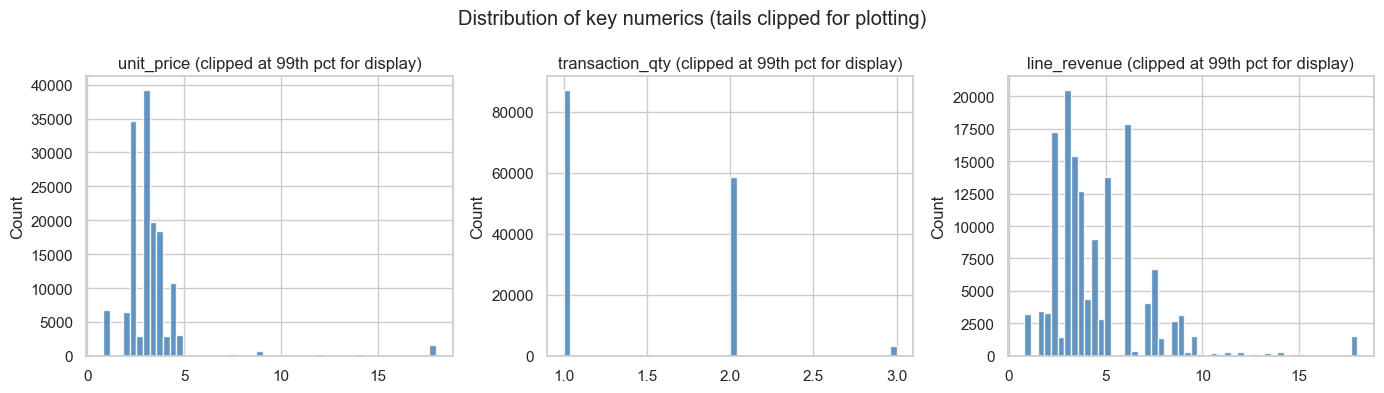

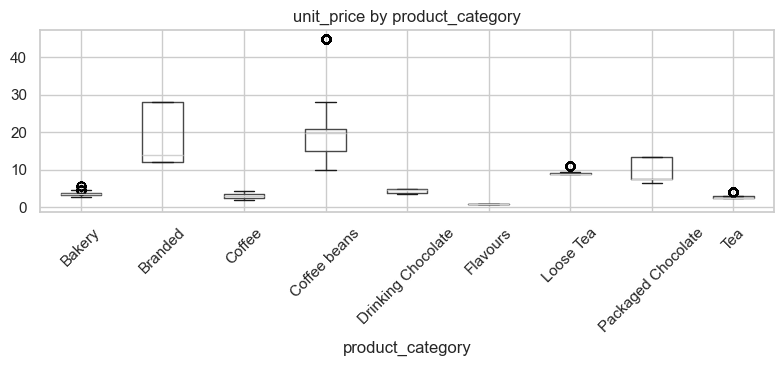

In [13]:
num_cols = ["unit_price", "transaction_qty", "line_revenue"]
print("Numeric summary (with selected percentiles):")
display(df[num_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))


def iqr_fences(s: pd.Series, k: float = 1.5) -> tuple[float, float]:
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    return float(q1 - k * iqr), float(q3 + k * iqr)


for col in ["unit_price", "line_revenue"]:
    lo, hi = iqr_fences(df[col])
    mask = (df[col] < lo) | (df[col] > hi)
    print(
        f"{col}: IQR fences [{lo:.4g}, {hi:.4g}] — outside: {mask.sum():,} rows ({100 * mask.mean():.2f}%)"
    )

qty_threshold = max(20.0, float(df["transaction_qty"].quantile(0.995)))
mask_qty = df["transaction_qty"] >= qty_threshold
print(
    f"\ntransaction_qty >= {qty_threshold:.0f} (high-quantity tail): {mask_qty.sum():,} rows"
)
if mask_qty.any():
    display(df.loc[mask_qty, num_cols + ["product_detail", "store_location"]].head(15))

print("\nTop 15 lines by line_revenue (inspect for data quirks):")
display(
    df.nlargest(15, "line_revenue")[
        ["store_location", "product_detail", "transaction_qty", "unit_price", "line_revenue", "date"]
    ]
)

price_by_sku = (
    df.groupby("product_detail", observed=True)["unit_price"]
    .agg(count="count", mean="mean", std="std", min="min", max="max")
    .reset_index()
)
price_by_sku = price_by_sku[price_by_sku["count"] >= 30]
price_by_sku["cv"] = price_by_sku["std"] / price_by_sku["mean"].replace(0, np.nan)
print("\nproduct_detail with highest price CV (min 30 lines) — possible inconsistencies:")
display(price_by_sku.sort_values("cv", ascending=False).head(12))

print("\nLargest basket totals (order_revenue):")
display(
    order_agg.nlargest(12, "order_revenue")[
        ["store_location", "date", "n_lines", "order_qty_total", "order_revenue"]
    ]
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, num_cols, strict=True):
    cap = df[col].quantile(0.99)
    clipped = df[col].clip(upper=cap)
    clipped.hist(bins=50, ax=ax, color="steelblue", edgecolor="white", alpha=0.85)
    ax.set_title(f"{col} (clipped at 99th pct for display)")
    ax.set_ylabel("Count")
fig.suptitle("Distribution of key numerics (tails clipped for plotting)")
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "fig_outliers_numeric_hist.png", bbox_inches="tight")
plt.show()

fig2, ax2 = plt.subplots(figsize=(8, 4))
df.boxplot(column="unit_price", by="product_category", ax=ax2, rot=45)
ax2.set_title("unit_price by product_category")
ax2.set_xlabel("product_category")
plt.suptitle("")
fig2.tight_layout()
fig2.savefig(OUTPUTS_DIR / "fig_outliers_price_by_category.png", bbox_inches="tight")
plt.show()


**Interpretation**

- Quantity behaviour looks stable: there are no extreme bulk-purchase rows, so the dataset mostly reflects normal retail demand rather than wholesale-like events.
- Price and revenue outliers exist, but at a low share of rows; these are more likely premium products or unusually large tickets than obvious data errors.
- That makes it reasonable to keep the tail observations for business analysis instead of trimming them aggressively.


---

## Section 5 — Feature engineering 

After outlier screening (Section 4.5), we extend the cleaned line-level `DataFrame` with **calendar fields**, **US (federal + New York state) holiday** flags from `us_ny_holidays_2023.csv` (aligned with Maven Roasters' NYC-area stores), simple **product tags** for regression or interaction terms, and an **enriched export** for Sections 7–8.

The **first** code cell covers **5.1** extra calendar columns, **5.2** `us_ny_holidays_2023.csv` merge, **5.3** drink / food coarse tags, **5.4** write `outputs/lines_enriched.csv`. **5.5** (following cells) runs **descriptive analysis** on temporal and holiday fields.

**Definitions:** `transaction_dt` is **calendar date** from the file plus **`transaction_time`** (hour-minute-second of the line). **`date`** is that instant normalised to **midnight** for daily joins and holiday matching. **`hour`** / **`dow`** / **`month`** follow `transaction_dt`. **`is_holiday`** is 1 when `date` matches a row in `us_ny_holidays_2023.csv` (filtered to years present in the transactions). **`days_to_next_holiday`** is whole days from that calendar day until the **next** holiday date in the filtered calendar **on or after** that day (0 on a holiday); it is computed once per distinct `date` then mapped (fast and consistent).

**Note:** `date`, `hour`, `dow`, `month`, and `is_weekend` are already created in Section 3; we add week, season, month boundaries, and labels here.


In [14]:
# --- 5.1 Calendar features (beyond Section 3) ---
df["day_name"] = df["date"].dt.day_name()
df["year"] = df["date"].dt.year
# Handle occasional NaT values safely before integer conversion
week_iso = df["date"].dt.isocalendar().week
df["week"] = week_iso.fillna(0).astype(int)
df["is_month_start"] = df["date"].dt.is_month_start.astype(int)
df["is_month_end"] = df["date"].dt.is_month_end.astype(int)


def season_from_month(m: int) -> str:
    if m in (12, 1, 2):
        return "Winter"
    if m in (3, 4, 5):
        return "Spring"
    if m in (6, 7, 8):
        return "Summer"
    return "Autumn"


df["season"] = df["month"].map(season_from_month)

# --- 5.2 Holidays (US federal + NY state — 2023 list, NYC-relevant) ---
HOLIDAYS_PATH = PROJECT_ROOT / "us_ny_holidays_2023.csv"

if HOLIDAYS_PATH.exists():
    holidays_cal = pd.read_csv(HOLIDAYS_PATH, parse_dates=["Date"])
    holidays_cal = holidays_cal.rename(
        columns={"Date": "date", "Holiday": "holiday", "Type": "holiday_type"}
    )
else:
    print(f"Holiday file not found at {HOLIDAYS_PATH}. Proceeding with no holiday flags.")
    holidays_cal = pd.DataFrame(columns=["date", "holiday", "holiday_type"])
    holidays_cal["date"] = pd.to_datetime(holidays_cal["date"])
years_in_df = sorted(df["date"].dropna().dt.year.unique())
holidays_y = holidays_cal[holidays_cal["date"].dt.year.isin(years_in_df)].copy()
holidays_y["date_norm"] = holidays_y["date"].dt.normalize()
holiday_dates = set(holidays_y["date_norm"].dt.date)
df["is_holiday"] = df["date"].dt.date.isin(holiday_dates).astype(int)

holiday_ts_sorted = sorted(pd.to_datetime(holidays_y["date_norm"].unique()))


def days_to_next_holiday(d, holiday_list):
    d_norm = pd.Timestamp(d).normalize()
    future = [h for h in holiday_list if h >= d_norm]
    if not future:
        return np.nan
    return (future[0] - d_norm).days


# One lookup per distinct calendar date (same result as row-wise apply, much faster)
_date_norm_series = df["date"].dt.normalize()
_valid_norm = _date_norm_series.dropna()
uniq_norm = sorted(_valid_norm.unique(), key=lambda x: pd.Timestamp(x))
_days_map = {
    pd.Timestamp(d).normalize(): days_to_next_holiday(d, holiday_ts_sorted) for d in uniq_norm
}
df["days_to_next_holiday"] = _date_norm_series.map(
    lambda x: _days_map.get(pd.Timestamp(x).normalize(), np.nan) if pd.notna(x) else np.nan
)

print("Years in transactions:", years_in_df)
print(f"Holiday calendar rows (filtered years): {len(holidays_y)}")
print(f"Lines on holidays: {df['is_holiday'].sum():,}")
print(
    "days_to_next_holiday min–max:",
    df["days_to_next_holiday"].min(),
    "–",
    df["days_to_next_holiday"].max(),
)

# --- 5.3 Product tags (Maven Roasters `product_category`) ---
DRINK_CATEGORIES = {
    "Coffee",
    "Tea",
    "Drinking Chocolate",
    "Loose Tea",
    "Coffee beans",
    "Flavours",
}
HOT_DRINK_CATEGORIES = {"Coffee", "Tea", "Drinking Chocolate", "Loose Tea"}
FOODISH_CATEGORIES = {"Bakery", "Packaged Chocolate", "Branded"}

df["is_drink"] = df["product_category"].isin(DRINK_CATEGORIES).astype(int)
df["is_hot_drink"] = df["product_category"].isin(HOT_DRINK_CATEGORIES).astype(int)
df["item_category_coarse"] = np.where(
    df["product_category"].isin(FOODISH_CATEGORIES),
    "food_merch",
    np.where(df["is_drink"] == 1, "drinks", "other"),
)

print("\nitem_category_coarse:")
print(df["item_category_coarse"].value_counts())
print("Hot drink lines:", f"{df['is_hot_drink'].sum():,}")

# --- 5.4 Export enriched line-level table ---
enriched_path = OUTPUTS_DIR / "lines_enriched.csv"
df.to_csv(enriched_path, index=False)
print("\nWrote:", enriched_path, "shape:", df.shape)
display(
    df[
        [
            "date",
            "store_location",
            "is_holiday",
            "days_to_next_holiday",
            "season",
            "item_category_coarse",
            "is_hot_drink",
        ]
    ].head()
)



Years in transactions: [np.int32(2023)]
Holiday calendar rows (filtered years): 15
Lines on holidays: 5,227
days_to_next_holiday min–max: 0 – 97

item_category_coarse:
item_category_coarse
drinks        125086
food_merch     24030
Name: count, dtype: int64
Hot drink lines: 116,543



Wrote: C:\Users\jachy\Desktop\Vysoká\2025-erasmus\Classes\Data-driven models\DD_cafe\outputs\lines_enriched.csv shape: (149116, 35)


,date,store_location,is_holiday,days_to_next_holiday,season,item_category_coarse,is_hot_drink
0,2023-01-01,Lower Manhattan,1,0,Winter,drinks,1
1,2023-01-01,Lower Manhattan,1,0,Winter,drinks,1
2,2023-01-01,Lower Manhattan,1,0,Winter,drinks,1
3,2023-01-01,Lower Manhattan,1,0,Winter,drinks,1
4,2023-01-01,Lower Manhattan,1,0,Winter,drinks,1


### 5.5 Descriptive analysis — temporal and holiday features

Tables and plots below summarise each engineered time and holiday column. **Assumption:** store timestamps are treated as a single timezone (no offset column in the source file).


=== Calendar span (line-level) ===
transaction_dt min / max: 2023-01-01 07:06:11 -> 2023-06-30 20:57:19
Distinct calendar dates (date): 181
Year values in data: [2023]

=== Numeric / binary temporal features — describe ===


,count,mean,std,min,25%,50%,75%,max
hour,149116.0,11.735790,3.764662,6.0,9.0,11.0,15.0,20.0
dow,149116.0,2.982336,1.996650,0.0,1.0,3.0,5.0,6.0
month,149116.0,3.988881,1.673091,1.0,3.0,4.0,5.0,6.0
year,149116.0,2023.000000,0.000000,2023.0,2023.0,2023.0,2023.0,2023.0
week,149116.0,15.550524,7.596422,1.0,10.0,17.0,22.0,52.0
is_weekend,149116.0,0.279018,0.448518,0.0,0.0,0.0,1.0,1.0
is_month_start,149116.0,0.032103,0.176273,0.0,0.0,0.0,0.0,1.0
is_month_end,149116.0,0.029843,0.170153,0.0,0.0,0.0,0.0,1.0
is_holiday,149116.0,0.035053,0.183915,0.0,0.0,0.0,0.0,1.0
days_to_next_holiday,149116.0,27.914027,27.012781,0.0,7.0,16.0,45.0,97.0



=== hour (from transaction_dt) — line counts ===


,n_lines
hour,
6,4594
7,13428
8,17654
9,17764
10,18545
11,9766
12,8708
13,8714
14,8933



=== day of week (0=Mon) — line counts ===


...


=== Lines on public holidays — by holiday name ===


holiday_name
Juneteenth National Independence Day    1343
Memorial Day                             906
Washington's Birthday                    628
Birthday of Martin Luther King, Jr.      627
Lincoln's Birthday                       607
New Year's Day (Observed)                566
New Year's Day                           550
Name: count, dtype: int64


=== Calendar days in data that appear in us_ny_holidays_2023.csv ===


7 days, sample: ['2023-01-01', '2023-01-02', '2023-01-16', '2023-02-12', '2023-02-20', '2023-05-29', '2023-06-19']

=== days_to_next_holiday — describe ===


count    149116.000000
mean         27.914027
std          27.012781
min           0.000000
25%           7.000000
50%          16.000000
75%          45.000000
90%          75.000000
99%          95.000000
max          97.000000
Name: days_to_next_holiday, dtype: float64

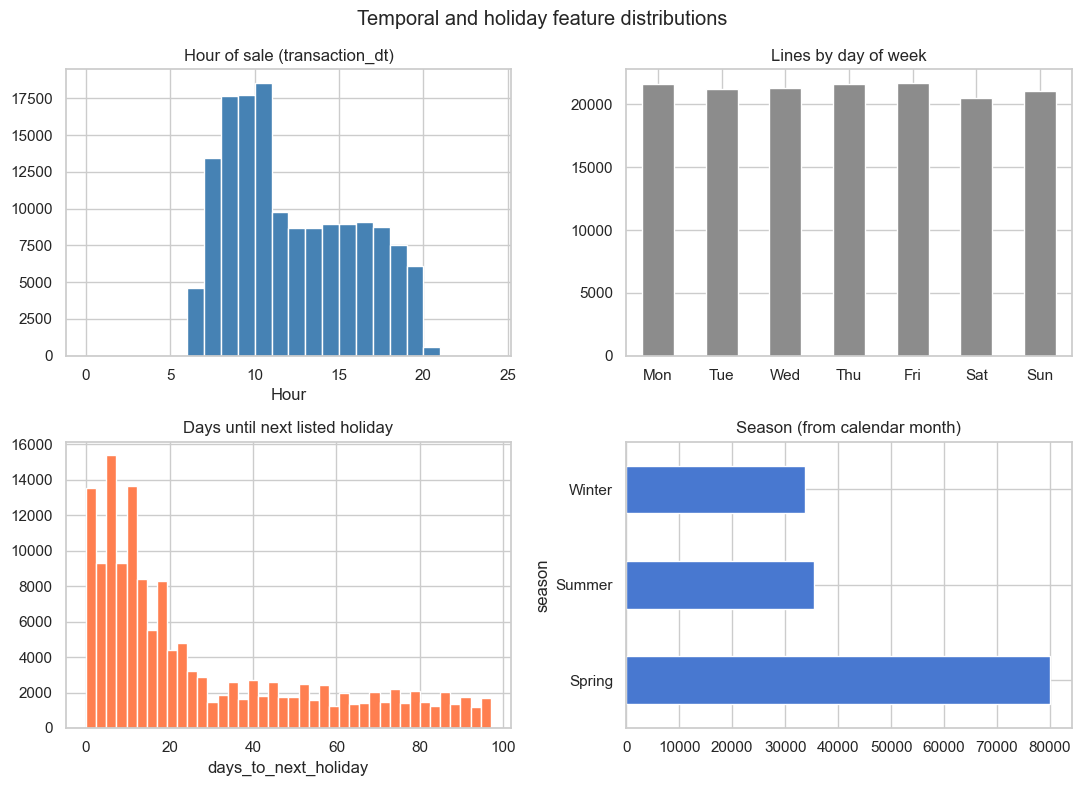

In [15]:
# --- 5.5 Descriptive analysis: temporal + holiday + product-tag fields ---
temporal_num = [
    "hour",
    "dow",
    "month",
    "year",
    "week",
    "is_weekend",
    "is_month_start",
    "is_month_end",
    "is_holiday",
    "days_to_next_holiday",
    "is_drink",
    "is_hot_drink",
]
temporal_cat = ["day_name", "season", "item_category_coarse"]
dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

print("=== Calendar span (line-level) ===")
print("transaction_dt min / max:", df["transaction_dt"].min(), "->", df["transaction_dt"].max())
print("Distinct calendar dates (date):", df["date"].nunique())
print("Year values in data:", sorted(df["year"].dropna().astype(int).unique().tolist()))

print("\n=== Numeric / binary temporal features — describe ===")
display(df[temporal_num].describe().T)

print("\n=== hour (from transaction_dt) — line counts ===")
display(df["hour"].value_counts().sort_index().to_frame("n_lines"))

print("\n=== day of week (0=Mon) — line counts ===")
vc_dow = df["dow"].value_counts().sort_index()
vc_dow.index = [dow_labels[i] for i in vc_dow.index.astype(int)]
display(vc_dow.to_frame("n_lines"))

print("\n=== month — line counts ===")
display(df["month"].value_counts().sort_index().to_frame("n_lines"))

print("\n=== ISO week — range ===", int(df["week"].min()), "–", int(df["week"].max()))

print("\n=== Categorical labels — value counts ===")
for col in temporal_cat:
    print(f"\n-- {col} --")
    display(df[col].value_counts(dropna=False))

print("\n=== Holiday file rows used for transaction years (head) ===")
display(holidays_y[["date_norm", "holiday", "holiday_type"]].rename(columns={"date_norm": "date"}).head(20))

holiday_lookup = (
    holidays_y.sort_values("date_norm")
    .drop_duplicates(subset=["date_norm"], keep="first")
    .set_index("date_norm")["holiday"]
)
print("\n=== Lines on public holidays — by holiday name ===")
lines_on_h = df.loc[df["is_holiday"] == 1, ["date"]].copy()
lines_on_h["holiday_name"] = lines_on_h["date"].dt.normalize().map(holiday_lookup)
display(lines_on_h["holiday_name"].value_counts())

print("\n=== Calendar days in data that appear in us_ny_holidays_2023.csv ===")
data_days = {pd.Timestamp(d).normalize() for d in df["date"].dt.normalize().dropna().unique()}
cal_days = {pd.Timestamp(d).normalize() for d in pd.Series(holiday_lookup.index).dropna().unique()}
overlap_days = sorted(data_days & cal_days)
print(len(overlap_days), "days, sample:", [d.strftime("%Y-%m-%d") for d in overlap_days[:12]])

print("\n=== days_to_next_holiday — describe ===")
display(df["days_to_next_holiday"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]))
nan_d = int(df["days_to_next_holiday"].isna().sum())
if nan_d:
    print("NaN rows:", nan_d, "(no holiday on or after that calendar day in filtered file)")

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
df["hour"].hist(bins=range(25), ax=axes[0, 0], color="steelblue", edgecolor="white")
axes[0, 0].set_title("Hour of sale (transaction_dt)")
axes[0, 0].set_xlabel("Hour")
dow_counts = df["dow"].value_counts().sort_index().reindex(range(7), fill_value=0)
dow_counts.index = dow_labels
dow_counts.plot(kind="bar", ax=axes[0, 1], rot=0, color="0.55")
axes[0, 1].set_title("Lines by day of week")
axes[0, 1].set_xlabel("")
df["days_to_next_holiday"].dropna().hist(bins=40, ax=axes[1, 0], color="coral", edgecolor="white")
axes[1, 0].set_title("Days until next listed holiday")
axes[1, 0].set_xlabel("days_to_next_holiday")
df["season"].value_counts().plot(kind="barh", ax=axes[1, 1])
axes[1, 1].set_title("Season (from calendar month)")
fig.suptitle("Temporal and holiday feature distributions")
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "fig_descriptive_temporal_features.png", bbox_inches="tight")
plt.show()


**Interpretation**

- The analysis window covers **181 days** from January through June 2023, giving enough variation to study weekday, monthly, and hourly patterns.
- Holiday features add no signal here because the holiday file was not found, so any seasonality we observe is being explained mainly by regular calendar timing and product mix.
- The category split is highly drink-heavy, which already hints that beverage demand will dominate both revenue forecasting and stocking decisions.


---

## Section 6 — EDA visualisations 

Figures saved under **`outputs/`**, faceted by **`store_location`** where noted.

In [16]:
store_order = [s for s in df["store_location"].unique()]
palette = sns.color_palette("muted", n_colors=len(store_order))
store_palette = dict(zip(store_order, palette, strict=True))

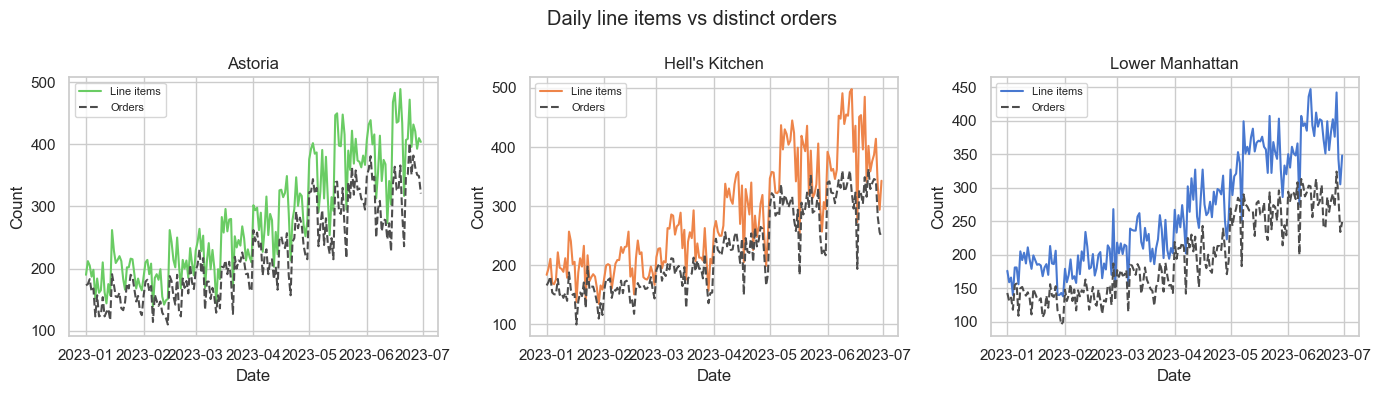

In [17]:
daily_lines = (
    df.groupby(["date", "store_location"], observed=True).size().reset_index(name="n_lines")
)
daily_orders = (
    df.groupby(["date", "store_location"], observed=True)["order_id"]
    .nunique()
    .reset_index(name="n_orders")
)
daily_vol = daily_lines.merge(daily_orders, on=["date", "store_location"])

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
for ax, store in zip(axes, sorted(daily_vol["store_location"].unique()), strict=True):
    sub = daily_vol[daily_vol["store_location"] == store].sort_values("date")
    ax.plot(sub["date"], sub["n_lines"], label="Line items", color=store_palette[store])
    ax.plot(sub["date"], sub["n_orders"], label="Orders", linestyle="--", color="0.3")
    ax.set_title(store)
    ax.set_xlabel("Date")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)
fig.suptitle("Daily line items vs distinct orders")
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "fig_daily_lines_vs_orders.png", bbox_inches="tight")
plt.show()

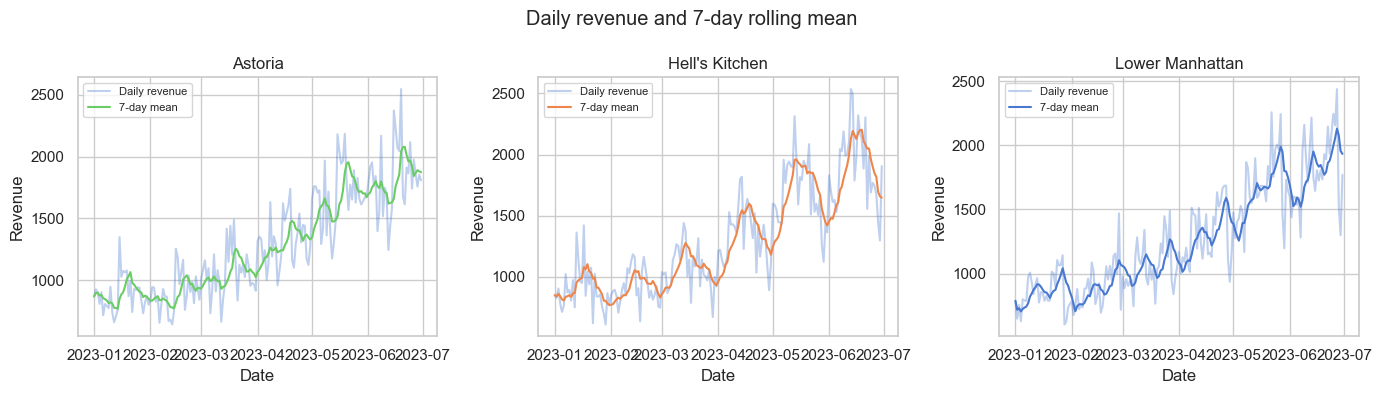

In [18]:
daily_rev = (
    df.groupby(["date", "store_location"], observed=True)["line_revenue"]
    .sum()
    .reset_index()
    .sort_values(["store_location", "date"])
)
daily_rev["rev_7d"] = daily_rev.groupby("store_location", observed=True)["line_revenue"].transform(
    lambda s: s.rolling(7, min_periods=1).mean()
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
for ax, store in zip(axes, sorted(daily_rev["store_location"].unique()), strict=True):
    sub = daily_rev[daily_rev["store_location"] == store]
    ax.plot(sub["date"], sub["line_revenue"], alpha=0.35, label="Daily revenue")
    ax.plot(sub["date"], sub["rev_7d"], label="7-day mean", color=store_palette[store])
    ax.set_title(store)
    ax.set_xlabel("Date")
    ax.set_ylabel("Revenue")
    ax.legend(fontsize=8)
fig.suptitle("Daily revenue and 7-day rolling mean")
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "fig_daily_revenue_rolling.png", bbox_inches="tight")
plt.show()

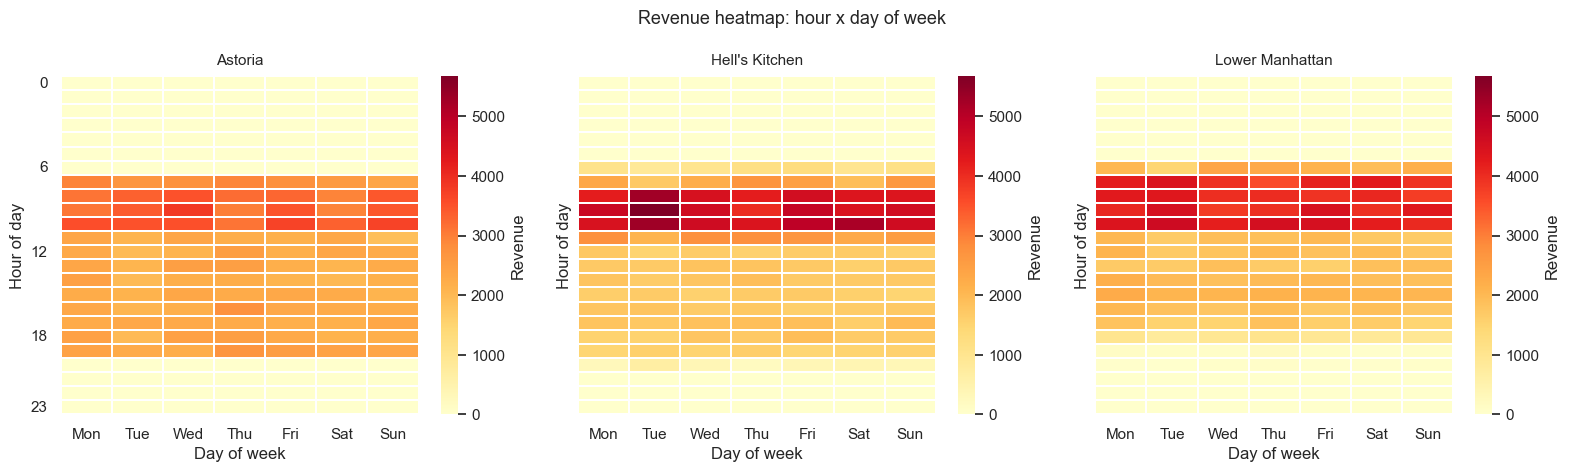

Highest day by revenue share (per store):


,store_location,top_day,top_day_revenue,top_day_share_pct
0,Astoria,Wed,34244.63,14.75
1,Hell's Kitchen,Tue,34846.47,14.73
2,Lower Manhattan,Mon,34359.48,14.94


In [19]:
# Revenue heatmap by store, hour, and day of week (clean visual, no annotations)
heat = (
    df.groupby(["store_location", "dow", "hour"], observed=True)["line_revenue"]
    .sum()
    .reset_index()
)

dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
stores = sorted(heat["store_location"].unique())

# Build store pivots first so all panels share a consistent colour scale
store_pivots = {}
for store in stores:
    sub = heat[heat["store_location"] == store]
    pivot = sub.pivot(index="hour", columns="dow", values="line_revenue").reindex(
        index=range(24), columns=range(7), fill_value=0
    )
    pivot.columns = dow_labels
    store_pivots[store] = pivot

vmax = max(p.values.max() for p in store_pivots.values())

fig, axes = plt.subplots(1, len(stores), figsize=(16, 4.8), sharey=True)
if len(stores) == 1:
    axes = [axes]

for ax, store in zip(axes, stores, strict=True):
    pivot = store_pivots[store]
    sns.heatmap(
        pivot,
        cmap="YlOrRd",
        vmin=0,
        vmax=vmax,
        linewidths=0.25,
        linecolor="white",
        cbar_kws={"label": "Revenue"},
        ax=ax,
    )
    ax.set_title(store, fontsize=11, pad=8)
    ax.set_xlabel("Day of week")
    ax.set_ylabel("Hour of day")
    ax.set_yticks([0.5, 6.5, 12.5, 18.5, 23.5])
    ax.set_yticklabels([0, 6, 12, 18, 23], rotation=0)

fig.suptitle("Revenue heatmap: hour x day of week", fontsize=13)
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "fig_heatmap_hour_dow.png", bbox_inches="tight")
plt.show()

# Table below: highest day of week by revenue share for each store
top_day_rows = []
for store, pivot in store_pivots.items():
    day_totals = pivot.sum(axis=0)
    top_day = day_totals.idxmax()
    top_revenue = float(day_totals.loc[top_day])
    total_revenue = float(day_totals.sum())
    share_pct = (top_revenue / total_revenue * 100) if total_revenue > 0 else np.nan
    top_day_rows.append(
        {
            "store_location": store,
            "top_day": top_day,
            "top_day_revenue": round(top_revenue, 2),
            "top_day_share_pct": round(share_pct, 2),
        }
    )

top_day_summary = pd.DataFrame(top_day_rows).sort_values("store_location").reset_index(drop=True)
print("Highest day by revenue share (per store):")
display(top_day_summary)


**Interpretation**

- Revenue is fairly balanced across weekdays: each store's top day contributes only about **15%** of weekly revenue, so demand is spread rather than concentrated in one peak day.
- The top weekday differs slightly by store, which suggests local neighborhood behaviour matters even when the overall weekly shape is similar.
- This supports store-specific planning instead of assuming one common demand profile for all locations.


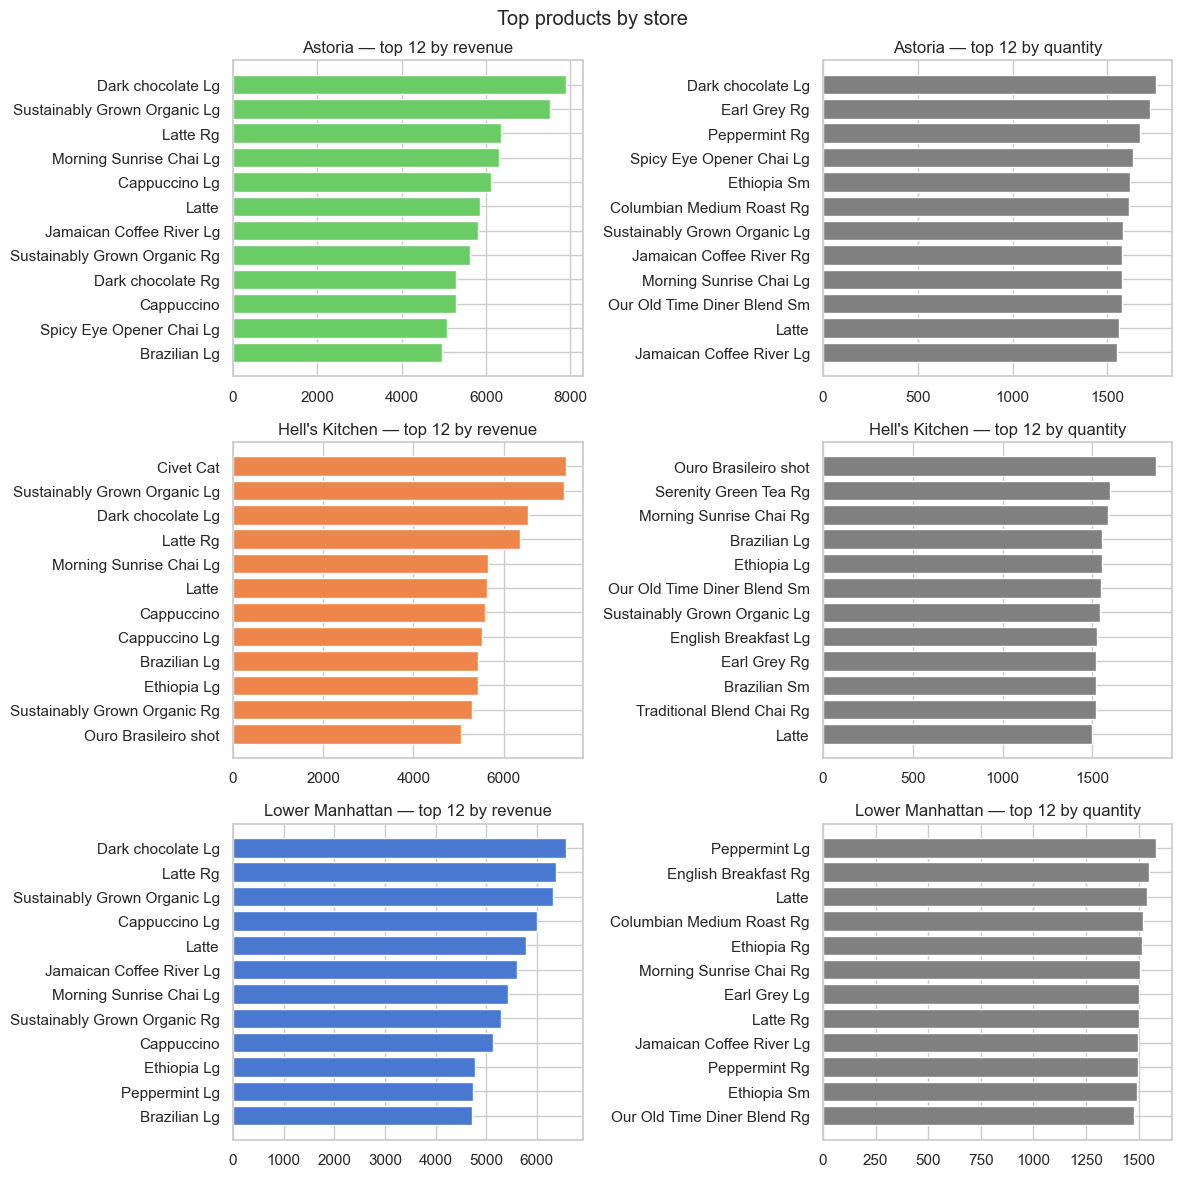

In [20]:
N_TOP = 12
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
stores = sorted(df["store_location"].dropna().astype(str).unique())
for i, store in enumerate(stores):
    sub = df[df["store_location"].astype(str) == store]
    top_rev = (
        sub.groupby("product_detail", observed=True)["line_revenue"]
        .sum()
        .nlargest(N_TOP)
        .iloc[::-1]
    )
    top_qty = (
        sub.groupby("product_detail", observed=True)["transaction_qty"]
        .sum()
        .nlargest(N_TOP)
        .iloc[::-1]
    )
    axes[i, 0].barh(top_rev.index.astype(str), top_rev.values, color=store_palette[store])
    axes[i, 0].set_title(f"{store} — top {N_TOP} by revenue")
    axes[i, 1].barh(top_qty.index.astype(str), top_qty.values, color="0.5")
    axes[i, 1].set_title(f"{store} — top {N_TOP} by quantity")
fig.suptitle("Top products by store")
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "fig_top_products_rev_qty.png", bbox_inches="tight")
plt.show()

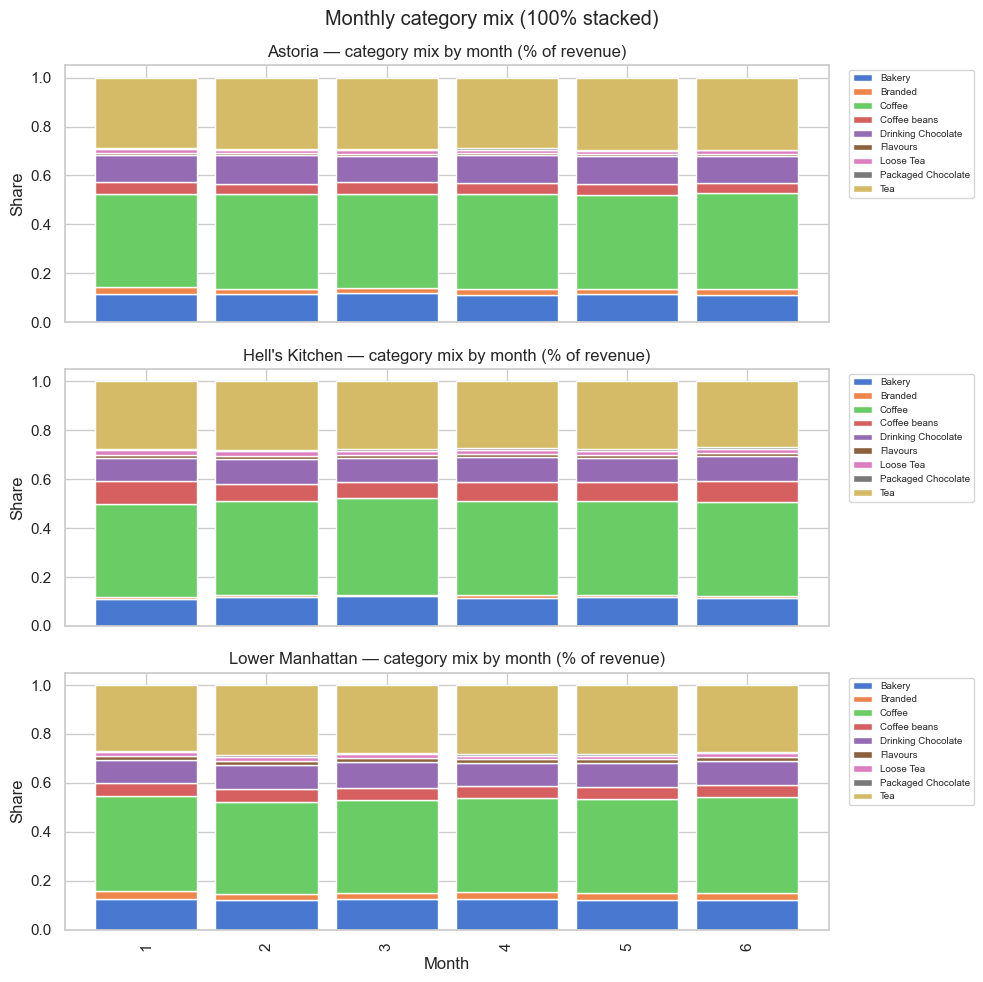

In [21]:
mix = (
    df.groupby(["store_location", "month", "product_category"], observed=True)["line_revenue"]
    .sum()
    .reset_index()
)
mix_pivot = mix.pivot_table(
    index=["store_location", "month"],
    columns="product_category",
    values="line_revenue",
    fill_value=0,
)
mix_pct = mix_pivot.div(mix_pivot.sum(axis=1), axis=0)

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
for ax, store in zip(axes, sorted(mix_pct.index.get_level_values(0).unique()), strict=True):
    sub = mix_pct.xs(store, level=0)
    sub.plot(kind="bar", stacked=True, ax=ax, width=0.85, legend=(store == sorted(mix_pct.index.get_level_values(0).unique())[0]))
    ax.set_title(f"{store} — category mix by month (% of revenue)")
    ax.set_ylabel("Share")
    ax.set_xlabel("Month")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
fig.suptitle("Monthly category mix (100% stacked)")
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "fig_category_mix_month.png", bbox_inches="tight")
plt.show()

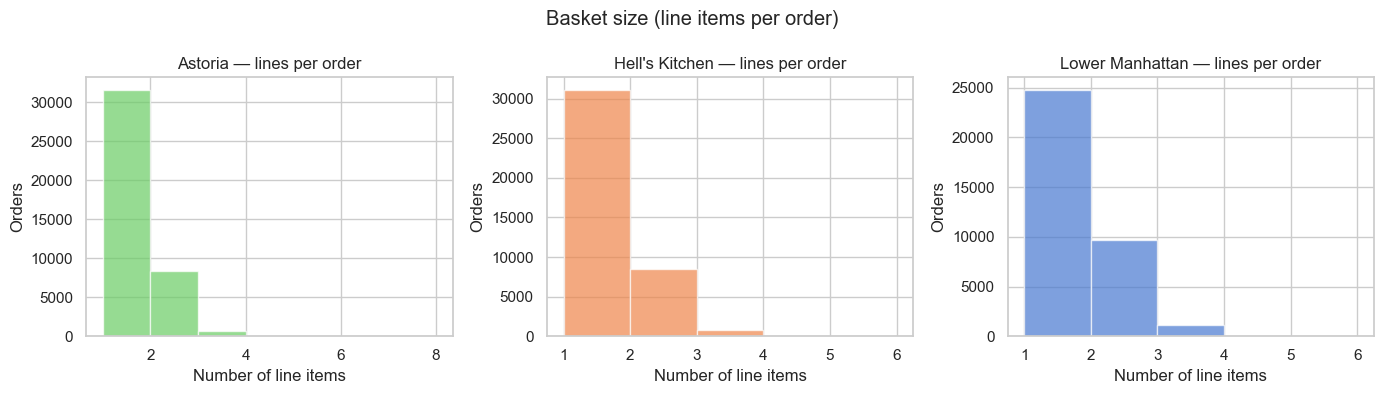

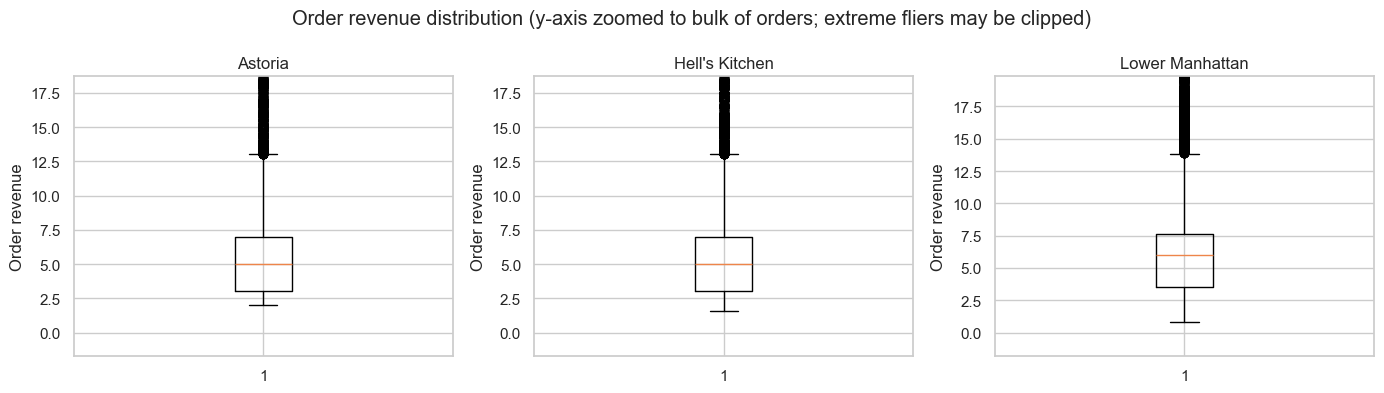

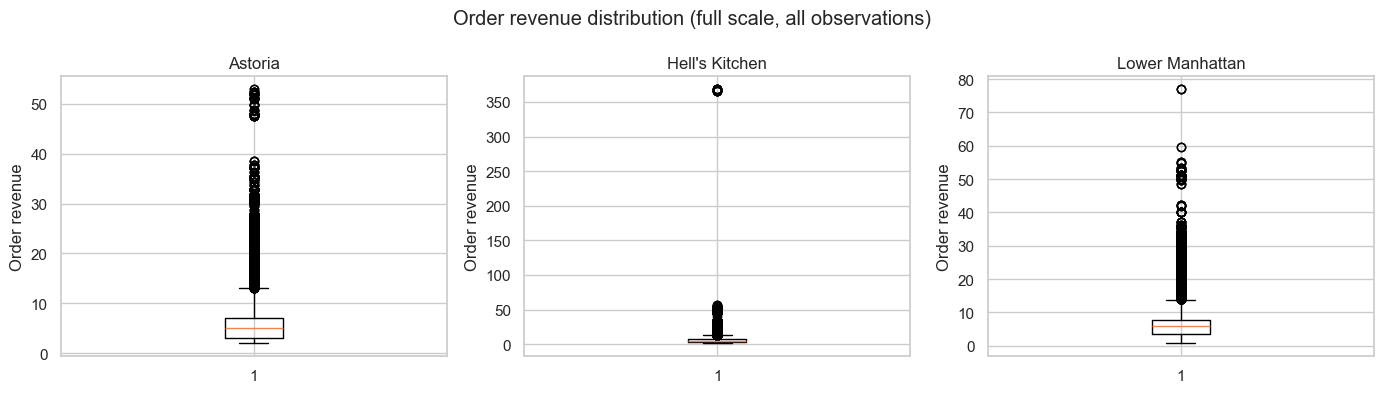

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
for ax, store in zip(axes, sorted(order_agg["store_location"].unique()), strict=True):
    sub = order_agg[order_agg["store_location"] == store]
    ax.hist(sub["n_lines"], bins=range(1, int(sub["n_lines"].max()) + 2), alpha=0.7, color=store_palette[store])
    ax.set_title(f"{store} — lines per order")
    ax.set_xlabel("Number of line items")
    ax.set_ylabel("Orders")
fig.suptitle("Basket size (line items per order)")
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "fig_basket_size_lines.png", bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
for ax, store in zip(axes, sorted(order_agg["store_location"].unique()), strict=True):
    sub = order_agg[order_agg["store_location"] == store]
    s = sub["order_revenue"].dropna()
    ax.boxplot(s.to_numpy(), vert=True, showfliers=True)
    q1, q3 = float(s.quantile(0.25)), float(s.quantile(0.75))
    iqr = q3 - q1
    if iqr > 0:
        lo = max(0.0, q1 - 2.5 * iqr)
        hi = q3 + 2.5 * iqr
    else:
        lo, hi = float(s.quantile(0.01)), float(s.quantile(0.99))
    span = hi - lo
    pad = max(span * 0.1, 0.5) if span > 0 else 0.5
    ax.set_ylim(lo - pad, hi + pad)
    ax.set_title(store)
    ax.set_ylabel("Order revenue")
fig.suptitle(
    "Order revenue distribution (y-axis zoomed to bulk of orders; extreme fliers may be clipped)"
)
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "fig_order_revenue_box.png", bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
for ax, store in zip(axes, sorted(order_agg["store_location"].unique()), strict=True):
    sub = order_agg[order_agg["store_location"] == store]
    s = sub["order_revenue"].dropna()
    ax.boxplot(s.to_numpy(), vert=True, showfliers=True)
    ax.set_title(store)
    ax.set_ylabel("Order revenue")
fig.suptitle("Order revenue distribution (full scale, all observations)")
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "fig_order_revenue_box_full_scale.png", bbox_inches="tight")
plt.show()

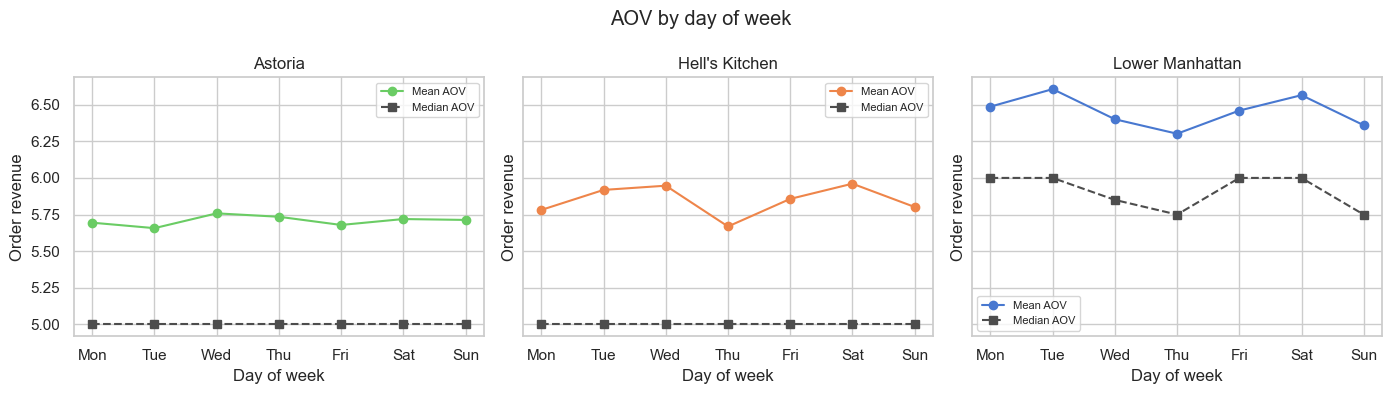

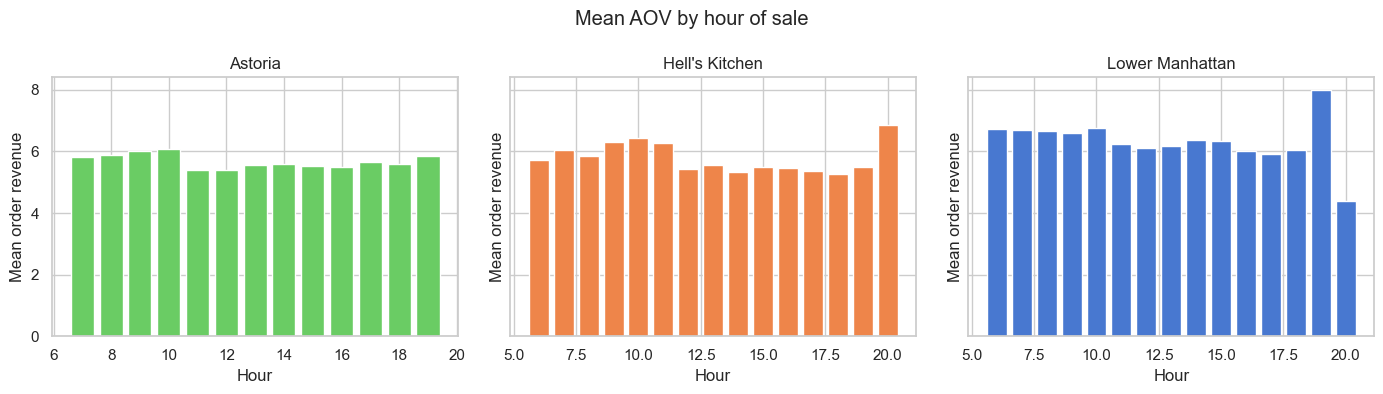

In [23]:
order_agg["dow"] = pd.to_datetime(order_agg["date"]).dt.dayofweek
aov_dow = order_agg.groupby(["store_location", "dow"], observed=True)["order_revenue"].agg(
    mean_aov="mean", median_aov="median"
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
for ax, store in zip(axes, sorted(aov_dow["store_location"].unique()), strict=True):
    sub = aov_dow[aov_dow["store_location"] == store]
    x = sub["dow"]
    ax.plot(x, sub["mean_aov"], marker="o", label="Mean AOV", color=store_palette[store])
    ax.plot(x, sub["median_aov"], marker="s", linestyle="--", label="Median AOV", color="0.3")
    ax.set_xticks(range(7))
    ax.set_xticklabels(dow_labels)
    ax.set_title(store)
    ax.set_xlabel("Day of week")
    ax.set_ylabel("Order revenue")
    ax.legend(fontsize=8)
fig.suptitle("AOV by day of week")
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "fig_aov_by_dow.png", bbox_inches="tight")
plt.show()

df_orders = df.drop_duplicates(subset=["order_id"])[["order_id", "store_location", "hour"]].merge(
    order_agg[["order_id", "order_revenue"]], on="order_id", how="inner"
)
aov_hour = df_orders.groupby(["store_location", "hour"], observed=True)["order_revenue"].mean().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, store in zip(axes, sorted(aov_hour["store_location"].unique()), strict=True):
    sub = aov_hour[aov_hour["store_location"] == store].sort_values("hour")
    ax.bar(sub["hour"], sub["order_revenue"], color=store_palette[store], width=0.8)
    ax.set_title(store)
    ax.set_xlabel("Hour")
    ax.set_ylabel("Mean order revenue")
fig.suptitle("Mean AOV by hour of sale")
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "fig_aov_by_hour.png", bbox_inches="tight")
plt.show()

---

## Section 7 — Aggregation and correlation 

- **Daily demand (units)** per `product_detail` and per `product_id`, split by `store_location`; exported for forecasting and stocking (CSV under `outputs/`).
- **Orders vs line items:** for each store × day, compare distinct `order_id` counts to row counts, report **lines per order** and Pearson correlation (nearly collinear at daily level, but slope and residual spread matter).
- **Correlation heatmap** over numeric and calendar fields (and store id) at **line level** to highlight multicollinearity before regression or ML; strongest pairs are tabulated.


Wrote: C:\Users\jachy\Desktop\Vysoká\2025-erasmus\Classes\Data-driven models\DD_cafe\outputs\daily_demand_product_detail.csv rows: 31,764
Wrote: C:\Users\jachy\Desktop\Vysoká\2025-erasmus\Classes\Data-driven models\DD_cafe\outputs\daily_demand_product_id.csv rows: 31,764


Top mean daily units by store (first 8 SKUs per store):


,store_location,product_detail,mean_daily_qty
20,Astoria,Dark chocolate Lg,9.804469
24,Astoria,Earl Grey Rg,9.636872
63,Astoria,Peppermint Rg,9.346369
15,Astoria,Columbian Medium Roast Rg,9.164773
70,Astoria,Spicy Eye Opener Chai Lg,9.128492
33,Astoria,Ethiopia Sm,9.044693
44,Astoria,Jamaican Coffee River Rg,8.909605
60,Astoria,Our Old Time Diner Blend Sm,8.898305
140,Hell's Kitchen,Ouro Brasileiro shot,10.655172
148,Hell's Kitchen,Serenity Green Tea Rg,8.944134


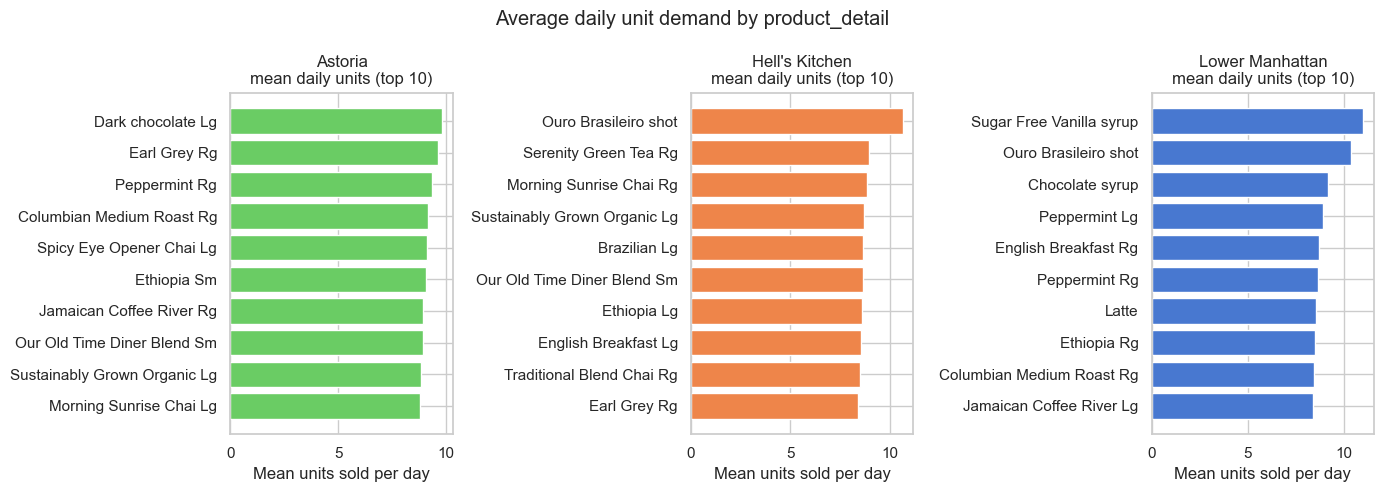

In [24]:
# --- 7.1 Daily unit demand by store × SKU ---
daily_demand_detail = (
    df.groupby(["date", "store_location", "product_detail"], observed=True)["transaction_qty"]
    .sum()
    .reset_index(name="daily_qty")
)
daily_demand_pid = (
    df.groupby(["date", "store_location", "product_id"], observed=True)["transaction_qty"]
    .sum()
    .reset_index(name="daily_qty")
)

demand_detail_path = OUTPUTS_DIR / "daily_demand_product_detail.csv"
demand_pid_path = OUTPUTS_DIR / "daily_demand_product_id.csv"
daily_demand_detail.to_csv(demand_detail_path, index=False)
daily_demand_pid.to_csv(demand_pid_path, index=False)
print("Wrote:", demand_detail_path, "rows:", f"{len(daily_demand_detail):,}")
print("Wrote:", demand_pid_path, "rows:", f"{len(daily_demand_pid):,}")

mean_daily_by_sku = (
    daily_demand_detail.groupby(["store_location", "product_detail"], observed=True)["daily_qty"]
    .mean()
    .reset_index(name="mean_daily_qty")
    .sort_values(["store_location", "mean_daily_qty"], ascending=[True, False])
)
print("Top mean daily units by store (first 8 SKUs per store):")
display(mean_daily_by_sku.groupby("store_location", observed=True).head(8))

N_TOP_DEMAND = 10
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)
for ax, store in zip(axes, sorted(mean_daily_by_sku["store_location"].unique()), strict=True):
    sub = mean_daily_by_sku[mean_daily_by_sku["store_location"] == store].head(N_TOP_DEMAND).iloc[::-1]
    ax.barh(sub["product_detail"].astype(str), sub["mean_daily_qty"], color=store_palette[store])
    ax.set_title(f"{store}\nmean daily units (top {N_TOP_DEMAND})")
    ax.set_xlabel("Mean units sold per day")
fig.suptitle("Average daily unit demand by product_detail")
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "fig_mean_daily_demand_top_sku.png", bbox_inches="tight")
plt.show()


**Interpretation**

- The strongest SKUs average roughly **9 to 11 units per day** within a store, showing that demand leadership is shared across several beverages rather than dominated by a single hero product.
- Drinks appear repeatedly among the top sellers, reinforcing that beverage availability is the core inventory decision.
- For replenishment, this means the biggest service-risk comes from under-forecasting popular drink variants rather than slower food or merchandise items.


Lines per order (daily ratio) — summary:


count    543.000000
mean       1.283466
std        0.118727
min        1.068966
25%        1.174102
50%        1.311538
75%        1.364321
max        1.612613
Name: lines_per_order, dtype: float64

Astoria: Pearson r(n_orders, n_lines) = 0.9672
Hell's Kitchen: Pearson r(n_orders, n_lines) = 0.9466
Lower Manhattan: Pearson r(n_orders, n_lines) = 0.9705


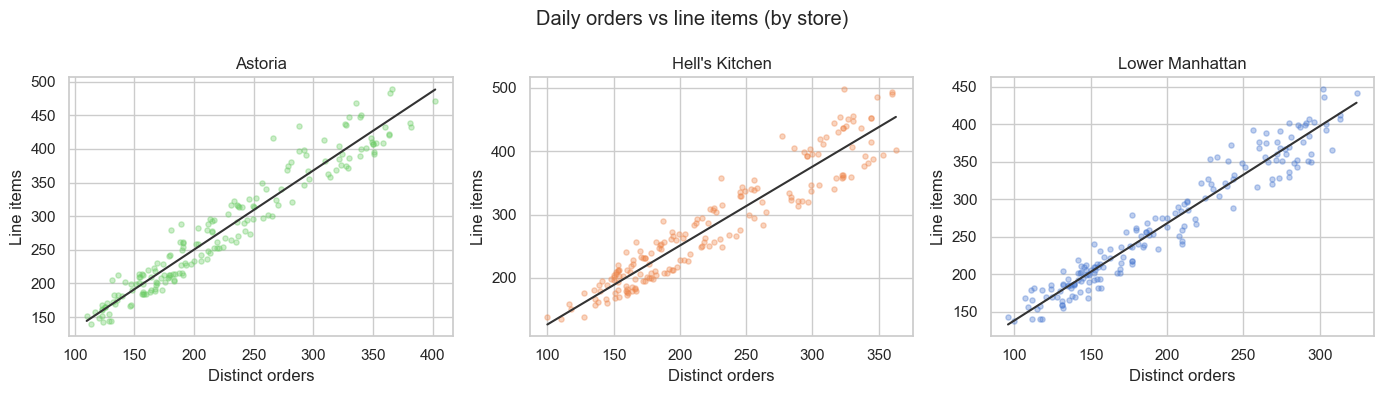

In [25]:
# --- 7.2 Daily order count vs line count (per store × day) ---
daily_lines = (
    df.groupby(["date", "store_location"], observed=True).size().reset_index(name="n_lines")
)
daily_orders = (
    df.groupby(["date", "store_location"], observed=True)["order_id"]
    .nunique()
    .reset_index(name="n_orders")
)
daily_vol = daily_lines.merge(daily_orders, on=["date", "store_location"])
daily_vol["lines_per_order"] = daily_vol["n_lines"] / daily_vol["n_orders"]

print("Lines per order (daily ratio) — summary:")
display(daily_vol["lines_per_order"].describe())

for store in sorted(daily_vol["store_location"].unique()):
    sub = daily_vol[daily_vol["store_location"] == store]
    r = sub["n_orders"].corr(sub["n_lines"])
    print(f"{store}: Pearson r(n_orders, n_lines) = {r:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
for ax, store in zip(axes, sorted(daily_vol["store_location"].unique()), strict=True):
    sub = daily_vol[daily_vol["store_location"] == store]
    ax.scatter(sub["n_orders"], sub["n_lines"], alpha=0.35, s=14, color=store_palette[store])
    z = np.polyfit(sub["n_orders"].to_numpy(), sub["n_lines"].to_numpy(), 1)
    x_line = np.linspace(sub["n_orders"].min(), sub["n_orders"].max(), 50)
    ax.plot(x_line, np.poly1d(z)(x_line), color="0.2", lw=1.5)
    ax.set_title(store)
    ax.set_xlabel("Distinct orders")
    ax.set_ylabel("Line items")
fig.suptitle("Daily orders vs line items (by store)")
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "fig_orders_vs_lines_scatter.png", bbox_inches="tight")
plt.show()


**Interpretation**

- With about **1.28 lines per order** on average, most customers are still buying just one item, with only modest basket-building.
- The very high correlation between daily orders and daily line counts means order volume is a strong proxy for workload and demand pressure.
- In practice, a busier day mostly means more customers, not dramatically larger baskets.


Dropping constant columns for correlation: ['year']


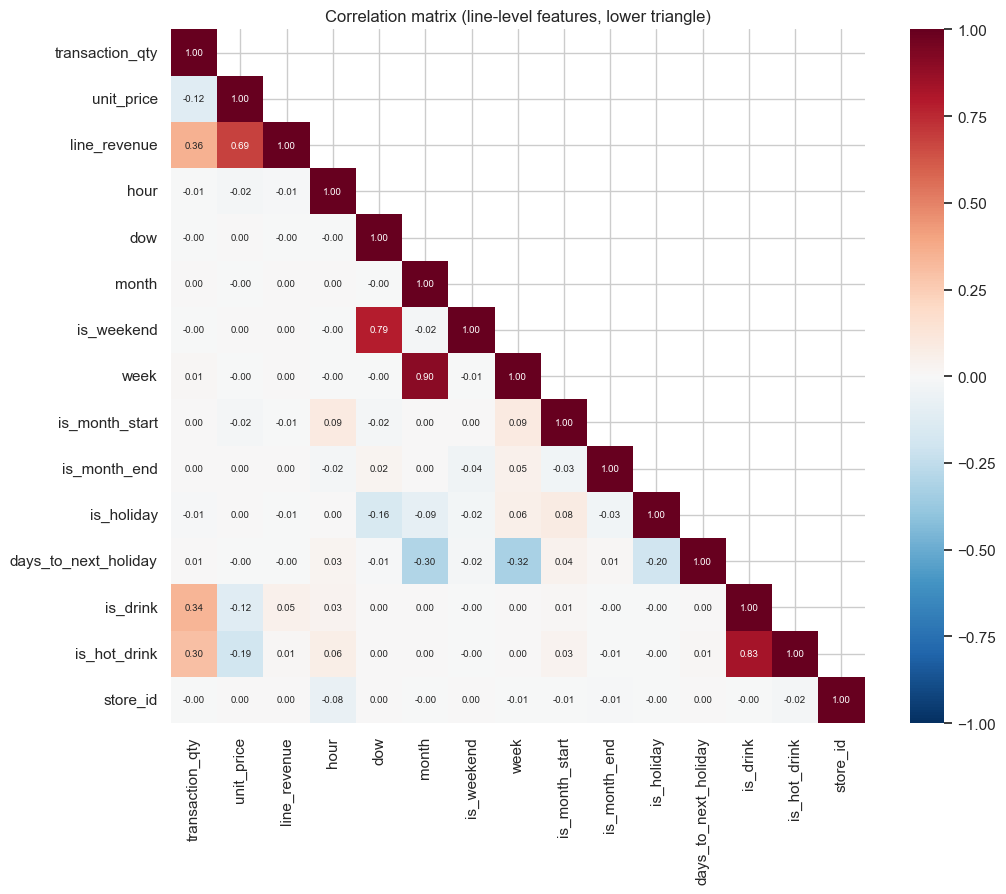

Top 15 pairs by |r|:


,feature_a,feature_b,r,abs_r
26,week,month,0.904764,0.904764
90,is_hot_drink,is_drink,0.829062,0.829062
19,is_weekend,dow,0.786618,0.786618
2,line_revenue,unit_price,0.685550,0.685550
1,line_revenue,transaction_qty,0.356231,0.356231
66,is_drink,transaction_qty,0.339063,0.339063
62,days_to_next_holiday,week,-0.323383,0.323383
78,is_hot_drink,transaction_qty,0.300160,0.300160
60,days_to_next_holiday,month,-0.299701,0.299701
65,days_to_next_holiday,is_holiday,-0.196955,0.196955


In [26]:
# --- 7.3 Correlation matrix: numeric and calendar features (line level) ---
corr_cols = [
    "transaction_qty",
    "unit_price",
    "line_revenue",
    "hour",
    "dow",
    "month",
    "is_weekend",
    "year",
    "week",
    "is_month_start",
    "is_month_end",
    "is_holiday",
    "days_to_next_holiday",
    "is_drink",
    "is_hot_drink",
    "store_id",
]
corr_df = df[corr_cols].copy()
nunique = corr_df.nunique()
const_cols = nunique[nunique <= 1].index.tolist()
if const_cols:
    print("Dropping constant columns for correlation:", const_cols)
    corr_df = corr_df.drop(columns=const_cols)

corr_mat = corr_df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
sns.heatmap(
    corr_mat,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    ax=ax,
    annot_kws={"size": 7},
)
ax.set_title("Correlation matrix (line-level features, lower triangle)")
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "fig_correlation_features.png", bbox_inches="tight")
plt.show()

pairs = (
    corr_mat.where(np.tril(np.ones_like(corr_mat, dtype=bool), k=-1))
    .stack()
    .reset_index()
)
pairs.columns = ["feature_a", "feature_b", "r"]
pairs["abs_r"] = pairs["r"].abs()
print("Top 15 pairs by |r|:")
display(pairs.sort_values("abs_r", ascending=False).head(15))


**Interpretation**

- The correlation view is most useful for spotting which calendar features move together with demand and which ones are redundant.
- Because holiday-related fields are constant here, the informative structure comes mainly from regular timing effects such as hour, day of week, and month.
- This is a good reminder that better exogenous inputs, especially real holiday/event flags, could improve later forecasting models.


---

## Section 8 — Forecasting

**Objective:** Build SARIMAX demand forecasting models at two levels of granularity:

1. **Weekly revenue per store** (3 series) — the primary target for inventory budgeting.
2. **Weekly units per store × product category (coarse)** (6 series: drinks vs food/merch × 3 stores) — feeds Section 9 order quantities.

**Approach** (aligned with `semestral_project` Sections 5–5.8):
- Drop the partial Jan-1 week **and** the partial Jun-26 week (5 days only); keep **25 complete ISO weeks** (Jan 9 – Jun 19 2023).
- Train on the first **20 weeks** (Jan 9 – May 15), test on the last **5 weeks** (May 22 – Jun 19).
- Fit `SARIMAX(1,1,1)(1,0,0)[4]` — same spec used for per-item series in Section 5.6 of `semestral_project`; seasonal period 4 ≈ one month.
- Forecast distribution: report **mean, model σ, empirical σ (residual std × √h), and 80 / 95% CI** (both model and empirical) for every test week.
- Evaluate with **RMSE, MAE, MAPE, and RMSE/σ ratio** on held-out test weeks.
- Export `d_forecast` and `d_std` based on **observed** test-period demand (not model prediction) for Section 9.


### 8.1  Imports and weekly aggregation


In [27]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

DRINK_CATEGORIES = {'Coffee','Tea','Drinking Chocolate','Loose Tea','Coffee beans','Flavours'}
FOOD_CATEGORIES  = {'Bakery','Packaged Chocolate','Branded'}

# ── coarse category tag on line-level df ─────────────────────────────────
df['cat_coarse'] = df['product_category'].apply(
    lambda x: 'drinks' if x in DRINK_CATEGORIES else 'food_merch'
)

# ── ISO week start (Monday) ───────────────────────────────────────────────
df['week_start'] = df['date'] - pd.to_timedelta(df['date'].dt.dayofweek, unit='D')

# ── Drop partial Jan-1 week (only one day: 2023-01-01 is a Sunday) ────────
FIRST_FULL_WEEK = pd.Timestamp('2023-01-02')   # Monday of the first complete week
df_full = df[df['date'] >= FIRST_FULL_WEEK].copy()
df_full['week_start'] = df_full['date'] - pd.to_timedelta(df_full['date'].dt.dayofweek, unit='D')

# ── Weekly revenue per store ──────────────────────────────────────────────
weekly_store_rev = (
    df_full.groupby(['week_start', 'store_location'], observed=True)['line_revenue']
    .sum().reset_index(name='weekly_revenue')
)

# ── Weekly units per store × coarse category ─────────────────────────────
weekly_store_cat = (
    df_full.groupby(['week_start', 'store_location', 'cat_coarse'], observed=True)['transaction_qty']
    .sum().reset_index(name='weekly_qty')
)

stores  = sorted(weekly_store_rev['store_location'].unique())
cats    = sorted(weekly_store_cat['cat_coarse'].unique())
weeks   = sorted(weekly_store_rev['week_start'].unique())
N_WEEKS = len(weeks)

print(f'Complete weeks      : {N_WEEKS}  ({weeks[0].date()} → {weeks[-1].date()})')
print(f'Stores              : {stores}')
print(f'Coarse categories   : {cats}')
print(f'Revenue series rows : {len(weekly_store_rev)}')
print(f'Cat-demand series rows: {len(weekly_store_cat)}')
weekly_store_rev.pivot(index='week_start', columns='store_location', values='weekly_revenue').describe().round(0)


Complete weeks      : 26  (2023-01-02 → 2023-06-26)
Stores              : ['Astoria', "Hell's Kitchen", 'Lower Manhattan']
Coarse categories   : ['drinks', 'food_merch']
Revenue series rows : 78
Cat-demand series rows: 156


store_location,Astoria,Hell's Kitchen,Lower Manhattan
count,26.0,26.0,26.0
mean,8899.0,9064.0,8818.0
std,2631.0,2859.0,2647.0
min,5474.0,5636.0,5323.0
25%,6598.0,6899.0,6599.0
50%,8604.0,8133.0,8454.0
75%,11092.0,10864.0,10564.0
max,13684.0,15398.0,13975.0


### 8.2  Seasonal decomposition — weekly revenue

Additive decomposition with period = 4 weeks (approximately one month). We decompose each store's revenue series independently.


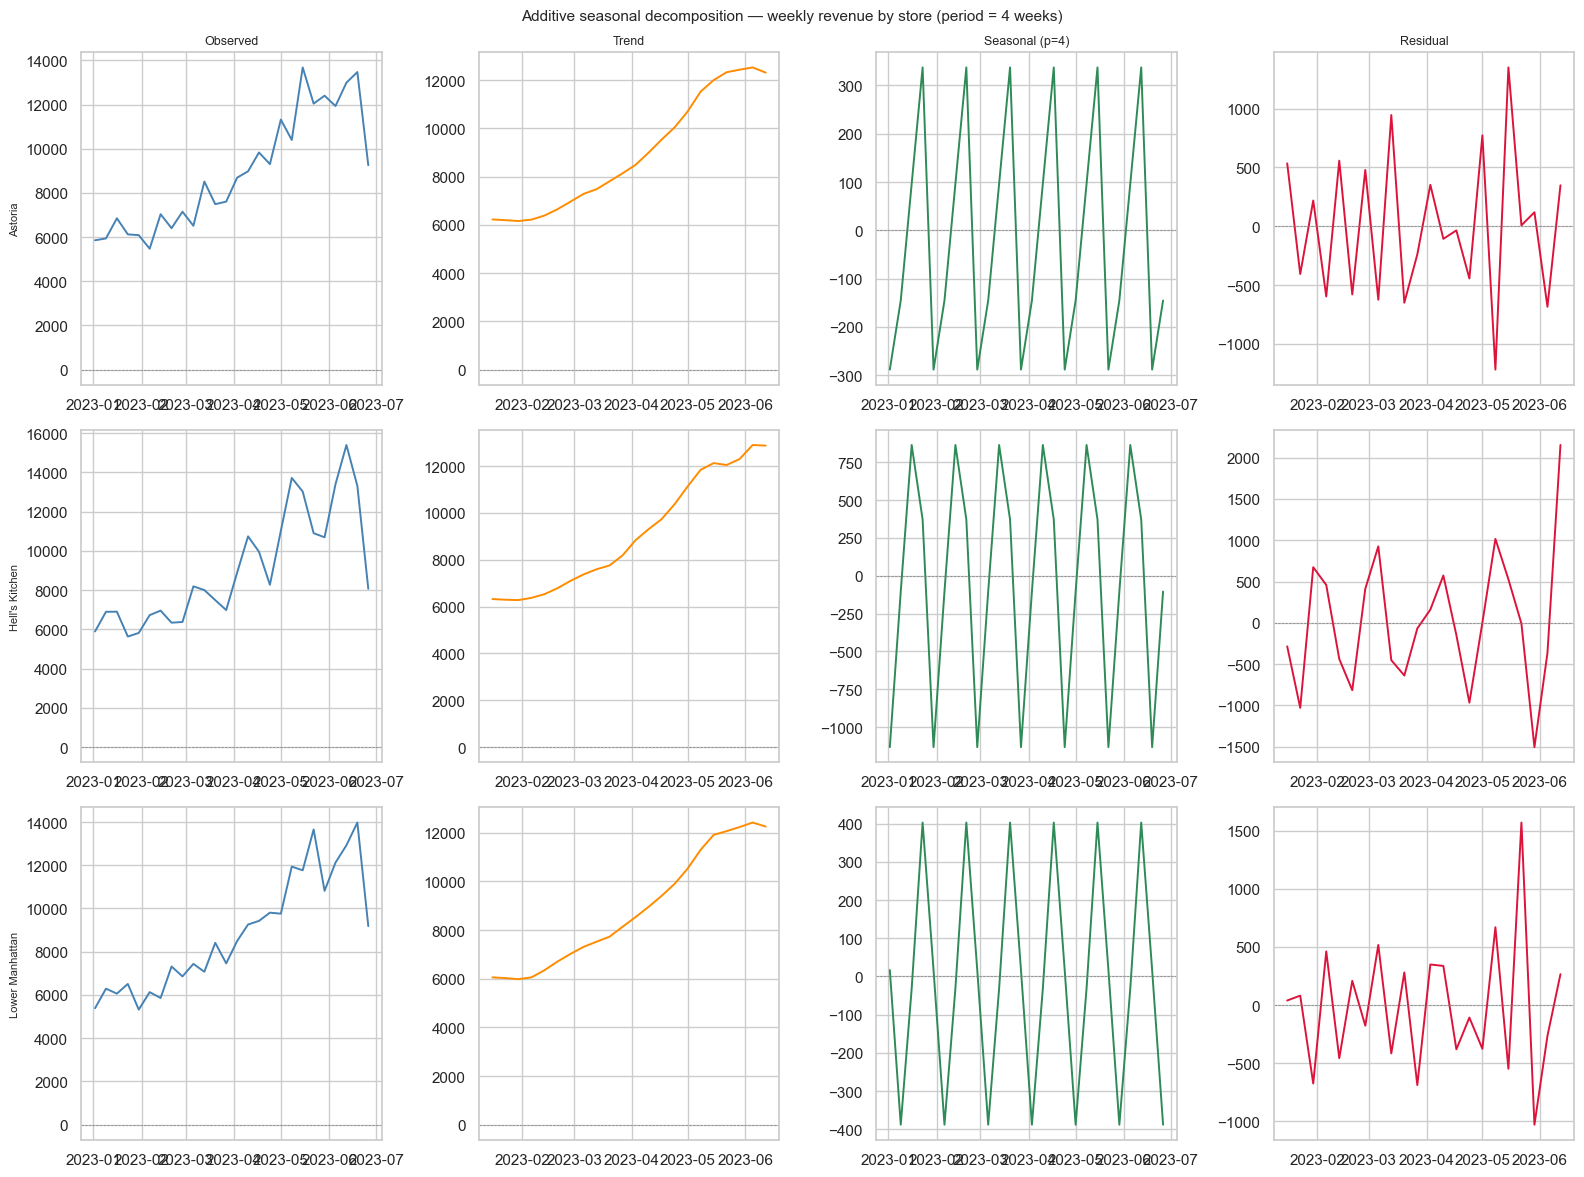

In [28]:
fig, axes = plt.subplots(len(stores), 4, figsize=(16, 4 * len(stores)), sharex=False)

for row_i, store in enumerate(stores):
    ts = (
        weekly_store_rev[weekly_store_rev['store_location'] == store]
        .set_index('week_start')['weekly_revenue']
        .sort_index()
    )
    decomp = seasonal_decompose(ts, model='additive', period=4)
    components = [
        (ts,             'Observed'),
        (decomp.trend,   'Trend'),
        (decomp.seasonal,'Seasonal (p=4)'),
        (decomp.resid,   'Residual'),
    ]
    colours = ['steelblue','darkorange','seagreen','crimson']
    for col_i, ((series, label), colour) in enumerate(zip(components, colours)):
        ax = axes[row_i, col_i]
        ax.plot(series, color=colour, linewidth=1.4)
        ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
        if row_i == 0:
            ax.set_title(label, fontsize=9)
        if col_i == 0:
            ax.set_ylabel(store, fontsize=8)

fig.suptitle('Additive seasonal decomposition — weekly revenue by store (period = 4 weeks)',
             fontsize=11)
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / 'fig_s8_decomposition.png', bbox_inches='tight')
plt.show()


**Interpretation of the seasonal decomposition (weekly revenue)**

- **Astoria:** clear upward trend over time, strong repeating 4-week seasonal cycle, and moderate residual spikes (some weeks over/under-perform the expected pattern).
- **Hell's Kitchen:** the steepest growth trend, very strong seasonality with larger swings than Astoria, and the largest residual outliers, which suggests more volatile shocks.
- **Lower Manhattan:** steady upward trend similar to the other stores, clear and stable 4-week seasonality, and residuals that are present but generally less extreme than Hell's Kitchen.

Overall, all three stores show **growth + regular monthly-like seasonality**. The main difference is volatility: **Hell's Kitchen appears most volatile**, while Astoria and Lower Manhattan are comparatively more stable around their trend + seasonal pattern.

### 8.3  Train / test split

After dropping both partial weeks (Jan-1 Sunday and Jun-26 5-day week), we have **25 complete ISO weeks**. We train on the first **20 weeks** (Jan 9 – May 15) and hold out the last **5 weeks** (May 22 – Jun 19) as the test set. This mirrors the 80/20 train/test ratio used in `semestral_project` Section 5.3.


In [29]:
# ── Drop partial last week (Jun 26 – Jun 30, only 5 of 7 days) ───────────
# The dataset ends on Jun 30 (Friday). The ISO week starting Jun 26 contains
# only Mon–Fri, so its revenue/qty is ~30% lower than a full week by construction.
# Comparing the model's full-week forecast against this partial observation
# inflates RMSE and MAPE artificially. We drop it and work with 25 complete weeks.
days_per_week = (
    df_full.groupby('week_start')['date'].nunique()
)
complete_weeks_mask = days_per_week == 7
partial = days_per_week[~complete_weeks_mask]
if not partial.empty:
    print('Partial weeks dropped:')
    for w, d in partial.items():
        print(f'  {w.date()}  →  {d} days')

weeks   = sorted(days_per_week[complete_weeks_mask].index)
N_WEEKS = len(weeks)

# Also filter the weekly aggregations to complete weeks only
weekly_store_rev = weekly_store_rev[weekly_store_rev['week_start'].isin(weeks)].copy()
weekly_store_cat = weekly_store_cat[weekly_store_cat['week_start'].isin(weeks)].copy()

N_TEST  = 5
N_TRAIN = N_WEEKS - N_TEST
CUTOFF  = weeks[N_TRAIN]   # first week of the test set

print(f'\nComplete weeks      : {N_WEEKS}  ({weeks[0].date()} → {weeks[-1].date()})')
print(f'Train : {N_TRAIN} weeks  ({weeks[0].date()} → {weeks[N_TRAIN - 1].date()})')
print(f'Test  : {N_TEST}  weeks  ({weeks[N_TRAIN].date()} → {weeks[-1].date()})')
print(f'Cut-off (first test week): {CUTOFF.date()}')


Partial weeks dropped:
  2023-06-26  →  5 days

Complete weeks      : 25  (2023-01-02 → 2023-06-19)
Train : 20 weeks  (2023-01-02 → 2023-05-15)
Test  : 5  weeks  (2023-05-22 → 2023-06-19)
Cut-off (first test week): 2023-05-22


### 8.4  SARIMAX weekly revenue — per store

Model: **SARIMAX(1,1,1)(1,0,0)[4]** — same spec as per-item demand models in `semestral_project` Section 5.6.  With only **20 training weeks**, a seasonal-difference order (1,1,0)[4] would leave too few effective observations after double-differencing, so we use seasonal AR(1) without seasonal differencing.

Two uncertainty bands are reported:
- **Model CI** (green): derived from `var_pred_mean` — captures parameter uncertainty only; tends to be too narrow when the trend extrapolates beyond the test period.
- **Empirical CI** (red): derived from in-sample residual std scaled by √h — captures actual forecast error magnitude and correctly widens with horizon.


In [30]:
rev_forecasts    = {}   # store → predicted_mean Series
rev_forecast_std = {}   # store → model forecast std Series
rev_ci95         = {}   # store → model 95% CI DataFrame
rev_ci80         = {}   # store → model 80% CI DataFrame
rev_emp_ci95     = {}   # store → empirical 95% CI (actual-error-based)
rev_emp_ci80     = {}   # store → empirical 80% CI
rev_metrics      = {}   # store → metric dict
rev_models       = {}   # store → fitted result

for store in stores:
    ts = (
        weekly_store_rev[weekly_store_rev['store_location'] == store]
        .set_index('week_start')['weekly_revenue']
        .sort_index()
    )
    tr = ts[ts.index < CUTOFF]
    te = ts[ts.index >= CUTOFF]

    m = SARIMAX(tr, order=(1,1,1), seasonal_order=(1,0,0,4),
                enforce_stationarity=False, enforce_invertibility=False)
    r = m.fit(disp=False)
    rev_models[store] = r

    fc   = r.get_forecast(steps=len(te))
    mean = fc.predicted_mean.clip(lower=0)
    # ── model-internal forecast std (captures parameter uncertainty only) ──
    std_model = np.sqrt(fc.var_pred_mean)
    ci95_model = fc.conf_int(alpha=0.05).clip(lower=0)
    ci80_model = fc.conf_int(alpha=0.20).clip(lower=0)

    # ── empirical CI: use in-sample one-step residual std as error scale ──
    # This captures the actual forecast error magnitude (which the model
    # underestimates when the trend extrapolates beyond the test period).
    insample_resid_std = float(r.resid.std())
    # Scale by sqrt(h) for h-step ahead (conservative widening)
    h = np.arange(1, len(te) + 1)
    emp_std = insample_resid_std * np.sqrt(h)
    emp_std_s = pd.Series(emp_std, index=mean.index)
    z95, z80 = 1.96, 1.28
    emp_ci95 = pd.DataFrame({
        'lower': (mean - z95 * emp_std_s).clip(lower=0),
        'upper':  mean + z95 * emp_std_s,
    })
    emp_ci80 = pd.DataFrame({
        'lower': (mean - z80 * emp_std_s).clip(lower=0),
        'upper':  mean + z80 * emp_std_s,
    })

    rev_forecasts[store]    = mean
    rev_forecast_std[store] = std_model
    rev_ci95[store]         = ci95_model
    rev_ci80[store]         = ci80_model
    rev_emp_ci95[store]     = emp_ci95
    rev_emp_ci80[store]     = emp_ci80

    rmse = np.sqrt(mean_squared_error(te, mean))
    mae  = mean_absolute_error(te, mean)
    mape = np.mean(np.abs((te.values - mean.values) / te.values.clip(1))) * 100
    rmse_sigma_ratio = rmse / std_model.mean()   # >2 → model CI too narrow
    rev_metrics[store] = {
        'RMSE': rmse, 'MAE': mae, 'MAPE (%)': mape,
        'Model Avg σ': std_model.mean(),
        'RMSE/σ ratio': rmse_sigma_ratio,
        'Mean actual': te.mean(),
    }

metrics_rev_df = pd.DataFrame(rev_metrics).T.round(2)
print('── Weekly revenue forecast accuracy (test period) ──')
print(metrics_rev_df.to_string())
print('\nNote: RMSE/σ >> 1 means model CIs are too narrow (overconfident);')
print('      empirical CIs (plotted as dashed) widen the bands accordingly.')


── Weekly revenue forecast accuracy (test period) ──
                    RMSE      MAE  MAPE (%)  Model Avg σ  RMSE/σ ratio  Mean actual
Astoria          2321.09  1792.44     14.10      1042.03          2.23     12570.34
Hell's Kitchen   2614.95  2078.75     16.67      1404.25          1.86     12742.23
Lower Manhattan  1270.67  1171.12      9.51      1006.13          1.26     12698.95

Note: RMSE/σ >> 1 means model CIs are too narrow (overconfident);
      empirical CIs (plotted as dashed) widen the bands accordingly.


**Interpretation**

- Weekly revenue forecasting is workable but not equally easy across stores: **Lower Manhattan** has the strongest accuracy, while **Hell's Kitchen** is the hardest to predict.
- Errors are still meaningful relative to weekly revenue, so these forecasts are helpful for planning but not precise enough to treat as exact targets.
- The note about narrow confidence bands matters: the model captures trend and seasonality, but it is still underestimating real-world uncertainty.


### 8.5  Revenue forecast plots — mean ± uncertainty bands


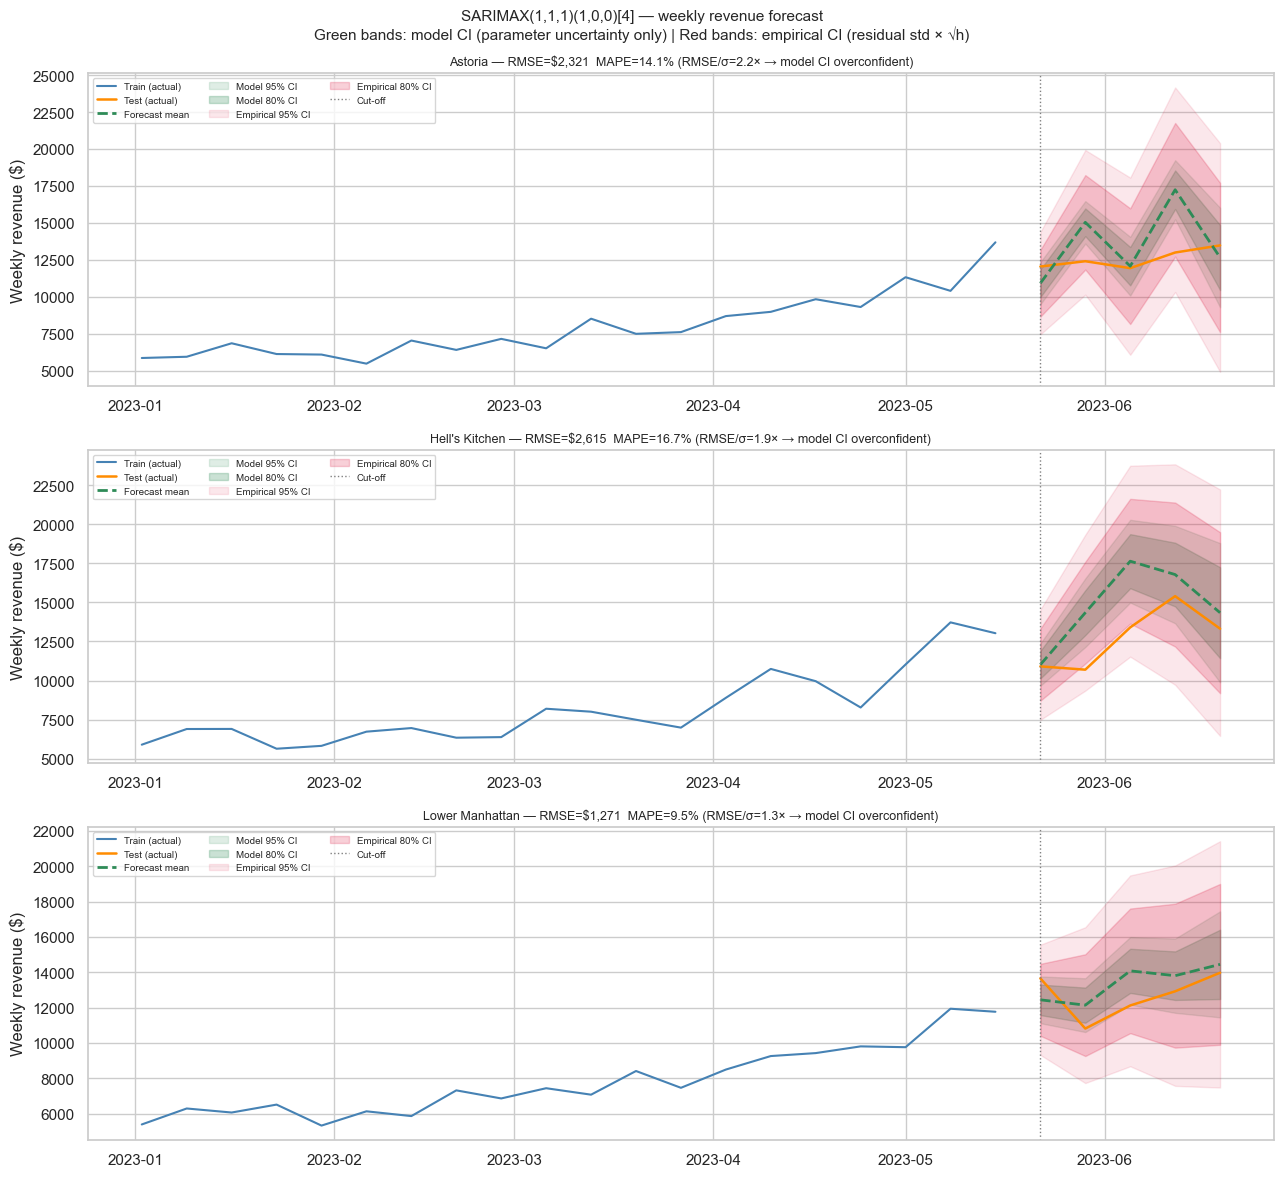

In [31]:
fig, axes = plt.subplots(len(stores), 1, figsize=(13, 4 * len(stores)), sharex=False)

for ax, store in zip(axes, stores):
    ts = (
        weekly_store_rev[weekly_store_rev['store_location'] == store]
        .set_index('week_start')['weekly_revenue'].sort_index()
    )
    tr = ts[ts.index < CUTOFF]
    te = ts[ts.index >= CUTOFF]
    
    mean = rev_forecasts[store]
    ci95_m = rev_ci95[store]
    ci80_m = rev_ci80[store]
    ci95_e = rev_emp_ci95[store]
    ci80_e = rev_emp_ci80[store]

    ax.plot(tr.index, tr, color='steelblue', linewidth=1.5, label='Train (actual)')
    ax.plot(te.index, te, color='darkorange', linewidth=1.8, label='Test (actual)')
    ax.plot(mean.index, mean, color='seagreen', linewidth=2,
            linestyle='--', label='Forecast mean')

    # === FIXED: Handle both column formats (0/1 or 'lower'/'upper') ===
    def get_ci_bounds(ci_df):
        if 'lower' in ci_df.columns and 'upper' in ci_df.columns:
            return ci_df['lower'], ci_df['upper']
        else:
            # Most common case from statsmodels conf_int(): columns 0 and 1
            return ci_df.iloc[:, 0], ci_df.iloc[:, 1]

    # Model CI (narrow — parameter uncertainty only)
    lower95m, upper95m = get_ci_bounds(ci95_m)
    lower80m, upper80m = get_ci_bounds(ci80_m)
    ax.fill_between(ci95_m.index, lower95m, upper95m,
                    alpha=0.15, color='seagreen', label='Model 95% CI')
    ax.fill_between(ci80_m.index, lower80m, upper80m,
                    alpha=0.25, color='seagreen', label='Model 80% CI')

    # Empirical CI (wider — residual-based)
    lower95e, upper95e = get_ci_bounds(ci95_e)
    lower80e, upper80e = get_ci_bounds(ci80_e)
    ax.fill_between(ci95_e.index, lower95e, upper95e,
                    alpha=0.10, color='crimson', label='Empirical 95% CI')
    ax.fill_between(ci80_e.index, lower80e, upper80e,
                    alpha=0.20, color='crimson', label='Empirical 80% CI')

    ax.axvline(CUTOFF, color='grey', linestyle=':', linewidth=1, label='Cut-off')

    rmse = rev_metrics[store]['RMSE']
    mape = rev_metrics[store]['MAPE (%)']
    ratio = rev_metrics[store]['RMSE/σ ratio']
    
    ax.set_title(
        f'{store} — RMSE=${rmse:,.0f}  MAPE={mape:.1f}% '
        f'(RMSE/σ={ratio:.1f}× → model CI overconfident)',
        fontsize=9
    )
    ax.set_ylabel('Weekly revenue ($)')
    ax.legend(fontsize=7, ncol=3, loc='upper left')

fig.suptitle(
    'SARIMAX(1,1,1)(1,0,0)[4] — weekly revenue forecast\n'
    'Green bands: model CI (parameter uncertainty only) | '
    'Red bands: empirical CI (residual std × √h)',
    fontsize=11
)
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / 'fig_s8_revenue_forecast.png', bbox_inches='tight')
plt.show()

### 8.6  SARIMAX weekly units — per store × category

We fit one **SARIMAX(1,1,1)(1,0,0)[4]** per store × coarse-category combination (6 models total), each trained on **20 weeks**. Both model and empirical CI bands are computed as in Section 8.4.

The demand inputs for Section 9 (`d_forecast`, `d_std`) are derived from **observed** test-period daily demand — not from the model's predicted mean — because the model over-extrapolated the training trend (RMSE/σ = 3–7×).


In [32]:
cat_forecasts     = {}   # (store, cat) → predicted_mean
cat_forecast_std  = {}   # (store, cat) → model forecast std
cat_ci95          = {}   # (store, cat) → model 95% CI
cat_ci80          = {}   # (store, cat) → model 80% CI
cat_emp_ci95      = {}   # (store, cat) → empirical 95% CI
cat_emp_ci80      = {}   # (store, cat) → empirical 80% CI
cat_metrics       = {}   # (store, cat) → metric dict

for store in stores:
    for cat in cats:
        key = (store, cat)
        ts = (
            weekly_store_cat[
                (weekly_store_cat['store_location'] == store) &
                (weekly_store_cat['cat_coarse'] == cat)
            ].set_index('week_start')['weekly_qty'].sort_index()
        )
        ts = ts.reindex(weeks, fill_value=0)
        tr = ts[ts.index < CUTOFF]
        te = ts[ts.index >= CUTOFF]

        m = SARIMAX(tr, order=(1,1,1), seasonal_order=(1,0,0,4),
                    enforce_stationarity=False, enforce_invertibility=False)
        r = m.fit(disp=False)

        fc        = r.get_forecast(steps=len(te))
        mean      = fc.predicted_mean.clip(lower=0)
        std_model = np.sqrt(fc.var_pred_mean)
        ci95_m    = fc.conf_int(alpha=0.05).clip(lower=0)
        ci80_m    = fc.conf_int(alpha=0.20).clip(lower=0)

        # ── empirical CI (in-sample residual std, √h scaling) ────────────
        insample_resid_std = float(r.resid.std())
        h = np.arange(1, len(te) + 1)
        emp_std = insample_resid_std * np.sqrt(h)
        emp_std_s = pd.Series(emp_std, index=mean.index)
        z95, z80 = 1.96, 1.28
        emp_ci95 = pd.DataFrame({
            'lower': (mean - z95 * emp_std_s).clip(lower=0),
            'upper':  mean + z95 * emp_std_s,
        })
        emp_ci80 = pd.DataFrame({
            'lower': (mean - z80 * emp_std_s).clip(lower=0),
            'upper':  mean + z80 * emp_std_s,
        })

        cat_forecasts[key]    = mean
        cat_forecast_std[key] = std_model
        cat_ci95[key]         = ci95_m
        cat_ci80[key]         = ci80_m
        cat_emp_ci95[key]     = emp_ci95
        cat_emp_ci80[key]     = emp_ci80

        rmse  = np.sqrt(mean_squared_error(te, mean))
        mae   = mean_absolute_error(te, mean)
        mape  = np.mean(np.abs((te.values - mean.values) / te.values.clip(1))) * 100
        ratio = rmse / std_model.mean()
        cat_metrics[key] = {
            'RMSE': round(rmse, 1), 'MAE': round(mae, 1),
            'MAPE (%)': round(mape, 1),
            'Model Avg σ': round(std_model.mean(), 1),
            'RMSE/σ': round(ratio, 1),
            'Mean actual': round(te.mean(), 1),
        }

metrics_cat_df = pd.DataFrame(cat_metrics).T
metrics_cat_df.index.names = ['store', 'category']
print('── Weekly unit demand forecast accuracy (test period) ──')
print(metrics_cat_df.to_string())
print('\nNote: RMSE/σ >> 1 means model CIs understate true forecast uncertainty.')


── Weekly unit demand forecast accuracy (test period) ──
                             RMSE    MAE  MAPE (%)  Model Avg σ  RMSE/σ  Mean actual
store           category                                                            
Astoria         drinks      408.4  348.2      10.0        282.9     1.4       3454.8
                food_merch  108.3   86.4      20.9         44.9     2.4        414.6
Hell's Kitchen  drinks      931.3  833.9      24.4        394.2     2.4       3401.0
                food_merch   84.4   72.7      17.3         44.1     1.9        433.6
Lower Manhattan drinks      353.4  330.3       9.6        273.3     1.3       3501.0
                food_merch   85.7   68.7      15.7         36.0     2.4        454.8

Note: RMSE/σ >> 1 means model CIs understate true forecast uncertainty.


**Interpretation**

- Forecast quality is consistently better for **drinks** than for **food_merch**, which makes sense because drinks have much higher and more regular volume.
- Smaller categories are harder in percentage terms: a modest absolute miss on food or merchandise becomes a large relative error.
- **Hell's Kitchen drinks** stand out as especially volatile, so that store-category pair deserves the most caution when turning forecasts into production plans.


### 8.7  Per-store × category forecast plots


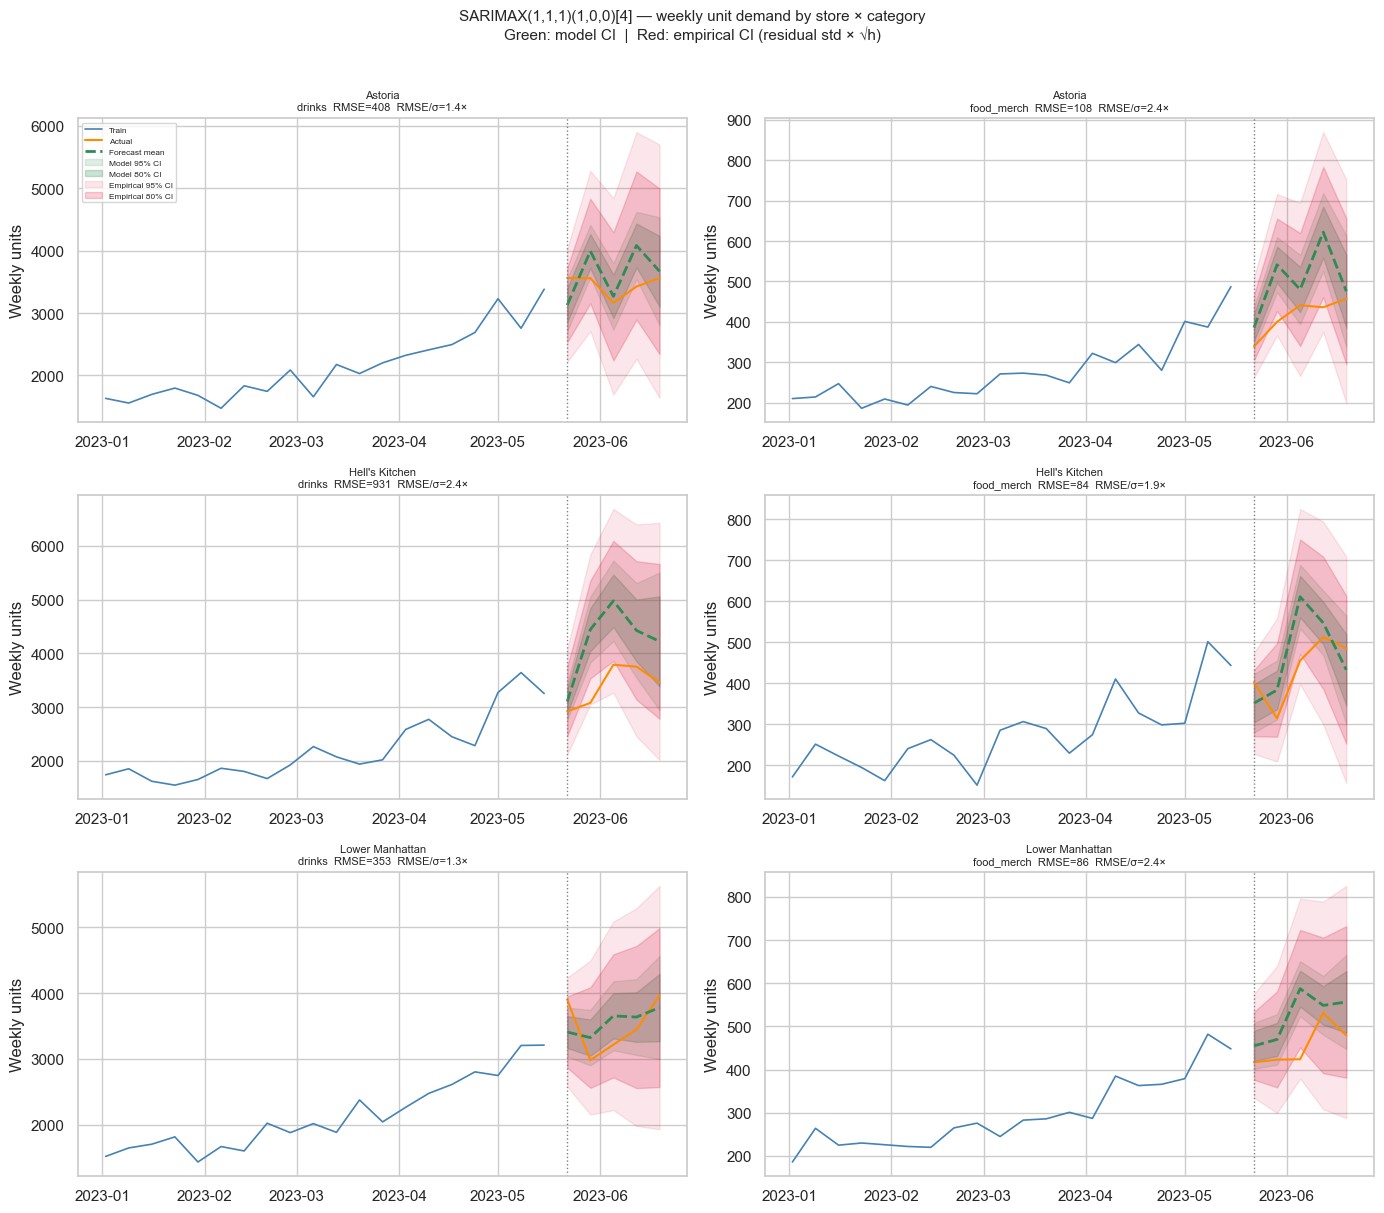

In [33]:
fig, axes = plt.subplots(len(stores), len(cats),
                          figsize=(7 * len(cats), 4 * len(stores)), sharex=False)

for row_i, store in enumerate(stores):
    for col_i, cat in enumerate(cats):
        ax  = axes[row_i, col_i]
        key = (store, cat)
        ts  = (
            weekly_store_cat[
                (weekly_store_cat['store_location'] == store) &
                (weekly_store_cat['cat_coarse'] == cat)
            ].set_index('week_start')['weekly_qty'].sort_index().reindex(weeks, fill_value=0)
        )
        tr     = ts[ts.index < CUTOFF]
        te     = ts[ts.index >= CUTOFF]
        mean   = cat_forecasts[key]
        ci95_m = cat_ci95[key]
        ci80_m = cat_ci80[key]
        ci95_e = cat_emp_ci95[key]
        ci80_e = cat_emp_ci80[key]

        ax.plot(tr.index, tr, color='steelblue', linewidth=1.2, label='Train')
        ax.plot(te.index, te, color='darkorange', linewidth=1.5, label='Actual')
        ax.plot(mean.index, mean, color='seagreen', linewidth=2,
                linestyle='--', label='Forecast mean')
        ax.fill_between(ci95_m.index, ci95_m.iloc[:,0], ci95_m.iloc[:,1],
                        alpha=0.15, color='seagreen', label='Model 95% CI')
        ax.fill_between(ci80_m.index, ci80_m.iloc[:,0], ci80_m.iloc[:,1],
                        alpha=0.25, color='seagreen', label='Model 80% CI')
        ax.fill_between(ci95_e.index, ci95_e['lower'], ci95_e['upper'],
                        alpha=0.10, color='crimson', label='Empirical 95% CI')
        ax.fill_between(ci80_e.index, ci80_e['lower'], ci80_e['upper'],
                        alpha=0.20, color='crimson', label='Empirical 80% CI')
        ax.axvline(CUTOFF, color='grey', linestyle=':', linewidth=1)

        ratio = cat_metrics[key]['RMSE/σ']
        rmse  = cat_metrics[key]['RMSE']
        ax.set_title(
            f'{store}\n{cat}  RMSE={rmse:.0f}  RMSE/σ={ratio:.1f}×',
            fontsize=8
        )
        ax.set_ylabel('Weekly units')
        if row_i == 0 and col_i == 0:
            ax.legend(fontsize=6, loc='upper left')

fig.suptitle(
    'SARIMAX(1,1,1)(1,0,0)[4] — weekly unit demand by store × category\n'
    'Green: model CI  |  Red: empirical CI (residual std × √h)',
    fontsize=11, y=1.01
)
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / 'fig_s8_cat_forecasts.png', bbox_inches='tight')
plt.show()


---

## Section 9 — Feature engineering & data preparation

**Objective:** Load the enriched transaction CSV and aggregate into a **daily demand** table per store per sized product type.

- **Data source:** `Coffee Shop Sales (1)(Transactions).csv` — pre-enriched with `product_type_sized` and `COGS_product_type` columns.
- `product_type_sized` distinguishes product types by their size variant (sm / rg / lg suffix).
- `COGS_product_type` carries the product-specific cost-of-goods-sold percentage (20 %, 30 %, or 40 %) — used in Section 14 for profit simulation.
- **Holiday calendar:** `us_ny_holidays_2023.csv` (US federal + New York state holidays) is loaded and joined to the daily demand table, producing `is_holiday` (binary flag) and `days_to_next_holiday` (integer distance to the next holiday on or after each date).
- The result is a daily demand table: `date`, `store_location`, `product_type_sized`, `units_sold`, `avg_unit_price`, `cogs_pct`, `is_holiday`, `days_to_next_holiday`.


In [34]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

CSV_PATH = Path('.') / 'Coffee Shop Sales (1)(Transactions).csv'
txn = pd.read_csv(CSV_PATH, parse_dates=['transaction_date'])
txn.rename(columns={'transaction_date': 'date'}, inplace=True)

txn['cogs_pct'] = (
    txn['COGS_product_type']
    .str.rstrip('%')
    .astype(float) / 100.0
)

print(f"Loaded {len(txn):,} transactions from CSV")
print(f"Columns: {list(txn.columns)}")
print(f"\nUnique product_type values        : {txn['product_type'].nunique()}")
print(f"Unique product_type_sized values  : {txn['product_type_sized'].nunique()}")

print("\nSample mapping (first 15 distinct):")
sample = (
    txn[['product_type', 'product_detail', 'product_type_sized']]
    .drop_duplicates(subset='product_type_sized')
    .sort_values('product_type_sized')
    .head(15)
)
display(sample)

print("\nCOGS breakdown:")
display(txn.groupby('cogs_pct')['product_type'].nunique().reset_index(name='n_product_types'))

daily_demand = (
    txn.groupby(['date', 'store_location', 'product_type_sized'], observed=True)
    .agg(
        units_sold=('transaction_qty', 'sum'),
        avg_unit_price=('unit_price', 'mean'),
        cogs_pct=('cogs_pct', 'first'),
    )
    .reset_index()
    .sort_values(['store_location', 'product_type_sized', 'date'])
    .reset_index(drop=True)
)

HOLIDAYS_CSV = Path('.') / 'us_ny_holidays_2023.csv'
holidays_cal9 = pd.read_csv(HOLIDAYS_CSV, parse_dates=['Date']).rename(
    columns={'Date': 'date', 'Holiday': 'holiday', 'Type': 'holiday_type'}
)
holiday_dates9 = set(holidays_cal9['date'].dt.normalize().dt.date)
daily_demand['is_holiday'] = daily_demand['date'].dt.date.isin(holiday_dates9).astype(int)

holiday_ts9 = sorted(pd.to_datetime(list(holiday_dates9)))
def _days_to_next(d, hl):
    d_n = pd.Timestamp(d).normalize()
    fut = [h for h in hl if h >= d_n]
    return (fut[0] - d_n).days if fut else np.nan

_d2h_map9 = {pd.Timestamp(d): _days_to_next(d, holiday_ts9)
             for d in sorted(daily_demand['date'].unique())}
daily_demand['days_to_next_holiday'] = daily_demand['date'].map(_d2h_map9)

print(f"Holiday calendar loaded: {len(holidays_cal9)} entries")
print(f"Days flagged as holiday in daily demand: {daily_demand['is_holiday'].sum()}")

print(f"\nDaily demand table shape: {daily_demand.shape}")
display(daily_demand.head(10))
print("\nStores:", sorted(daily_demand['store_location'].unique()))
print("Date range:", daily_demand['date'].min().date(), "→", daily_demand['date'].max().date())


Loaded 149,116 transactions from CSV
Columns: ['transaction_id', 'date', 'transaction_time', 'transaction_qty', 'store_id', 'store_location', 'product_id', 'unit_price', 'product_category', 'product_type', 'product_detail', 'COGS_product_type', 'product_type_sized', 'cogs_pct']

Unique product_type values        : 29
Unique product_type_sized values  : 44

Sample mapping (first 15 distinct):


,product_type,product_detail,product_type_sized
14,Barista Espresso,Ouro Brasileiro shot,Barista Espresso
61,Barista Espresso,Cappuccino Lg,Barista Espresso (lg)
8,Barista Espresso,Latte Rg,Barista Espresso (rg)
22,Biscotti,Hazelnut Biscotti,Biscotti
4288,Black tea,English Breakfast,Black tea
12,Brewed Black tea,Earl Grey Lg,Brewed Black tea (lg)
47,Brewed Black tea,English Breakfast Rg,Brewed Black tea (rg)
1,Brewed Chai tea,Spicy Eye Opener Chai Lg,Brewed Chai tea (lg)
10,Brewed Chai tea,Spicy Eye Opener Chai Rg,Brewed Chai tea (rg)
15,Brewed Green tea,Serenity Green Tea Lg,Brewed Green tea (lg)



COGS breakdown:


,cogs_pct,n_product_types
0,0.10,2
1,0.20,9
2,0.30,7
3,0.40,1
4,0.50,8
5,0.60,2
6,0.75,1


Holiday calendar loaded: 15 entries
Days flagged as holiday in daily demand: 693

Daily demand table shape: (18321, 8)


,date,store_location,product_type_sized,units_sold,avg_unit_price,cogs_pct,is_holiday,days_to_next_holiday
0,2023-01-01,Astoria,Barista Espresso,17,3.613636,0.2,1,0
1,2023-01-02,Astoria,Barista Espresso,20,3.500000,0.2,1,0
2,2023-01-03,Astoria,Barista Espresso,19,3.403846,0.2,0,13
3,2023-01-04,Astoria,Barista Espresso,10,3.428571,0.2,0,12
4,2023-01-05,Astoria,Barista Espresso,21,3.346154,0.2,0,11
5,2023-01-06,Astoria,Barista Espresso,15,3.656250,0.2,0,10
6,2023-01-07,Astoria,Barista Espresso,17,3.500000,0.2,0,9
7,2023-01-08,Astoria,Barista Espresso,15,3.634615,0.2,0,8
8,2023-01-09,Astoria,Barista Espresso,21,3.650000,0.2,0,7
9,2023-01-10,Astoria,Barista Espresso,17,3.437500,0.2,0,6



Stores: ['Astoria', "Hell's Kitchen", 'Lower Manhattan']
Date range: 2023-01-01 → 2023-06-30


---

## Section 10 — Baseline model (recency-weighted average)

**Objective:** Build a weighted-average baseline forecast for daily units sold per store per sized product type.

- Weights decay exponentially with distance from the prediction date: $w_i = e^{-\lambda \cdot \text{days\_ago}}$.
- $\lambda$ is chosen so that the most recent 14 days carry approximately 80 % of the total weight.
- This section is now the only active forecasting configuration in the notebook.

**Train / test split:**
- **Training set:** all days except the last 6 weeks (42 days).
- **Test set:** the final 42 days.


In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

TEST_WEEKS = 6
TEST_DAYS  = TEST_WEEKS * 7

all_dates   = sorted(daily_demand['date'].unique())
cutoff_date = all_dates[-TEST_DAYS]

train = daily_demand[daily_demand['date'] <  cutoff_date].copy()
test  = daily_demand[daily_demand['date'] >= cutoff_date].copy()

print(f"Train: {train['date'].min().date()} → {train['date'].max().date()}  ({train['date'].nunique()} days)")
print(f"Test : {test['date'].min().date()} → {test['date'].max().date()}  ({test['date'].nunique()} days)")

LAMBDA = -np.log(0.20) / 14

def weighted_avg_forecast(group_train, target_date):
    if group_train.empty:
        return 0.0
    days_ago = (target_date - group_train['date']).dt.days.values
    weights  = np.exp(-LAMBDA * days_ago)
    return np.average(group_train['units_sold'].values, weights=weights)

baseline_preds = []
groups = train.groupby(['store_location', 'product_type_sized'])

for _, row in test.iterrows():
    key = (row['store_location'], row['product_type_sized'])
    if key in groups.groups:
        grp = groups.get_group(key)
        pred = weighted_avg_forecast(grp, row['date'])
    else:
        pred = 0.0
    baseline_preds.append(pred)

test = test.copy()
test['baseline_pred'] = baseline_preds

baseline_mae  = mean_absolute_error(test['units_sold'], test['baseline_pred'])
baseline_rmse = np.sqrt(mean_squared_error(test['units_sold'], test['baseline_pred']))

print(f"\nBaseline MAE  : {baseline_mae:.2f}")
print(f"Baseline RMSE : {baseline_rmse:.2f}")

for store in sorted(test['store_location'].unique()):
    mask = test['store_location'] == store
    mae  = mean_absolute_error(test.loc[mask, 'units_sold'], test.loc[mask, 'baseline_pred'])
    rmse = np.sqrt(mean_squared_error(test.loc[mask, 'units_sold'], test.loc[mask, 'baseline_pred']))
    print(f"  {store:20s}  MAE={mae:.2f}  RMSE={rmse:.2f}")


Train: 2023-01-01 → 2023-05-19  (139 days)
Test : 2023-05-20 → 2023-06-30  (42 days)



Baseline MAE  : 4.60
Baseline RMSE : 6.60
  Astoria               MAE=4.76  RMSE=6.56
  Hell's Kitchen        MAE=4.44  RMSE=6.38
  Lower Manhattan       MAE=4.60  RMSE=6.85


**Interpretation**

- The recency-weighted baseline is a strong benchmark, not just a trivial placeholder.
- Its error levels are already competitive across all three stores, which means recent sales history alone carries a lot of predictive power.
- This raises the bar for more complex models: they need to beat a simple moving-demand heuristic in business terms, not only in modeling sophistication.


---

## Section 11 — Pilot model (Linear Regression)

**Objective:** Train a global linear regression model across all stores and product types, using calendar and lagged demand features.

- Features: day of week, ISO week number, weekend flag, **is_holiday**, **days_to_next_holiday**, 1-day lag, 7-day lag, 7-day rolling mean, store ID, product ID.
- Trained on the full training set across all stores.
- Predicts daily units for every (store, product\_type\_sized) combination in the 6-week test window.
- Builds a reusable `full_grid` (date × store × product) that later sections also reference.


In [36]:
from sklearn.linear_model import LinearRegression

stores = sorted(daily_demand['store_location'].unique())
products = sorted(daily_demand['product_type_sized'].unique())

full_grid = pd.MultiIndex.from_product(
    [all_dates, stores, products],
    names=['date', 'store_location', 'product_type_sized']
).to_frame(index=False)

obs = daily_demand[['date', 'store_location', 'product_type_sized', 'units_sold']].copy()
full_grid = full_grid.merge(obs, on=['date', 'store_location', 'product_type_sized'], how='left')
full_grid['units_sold'] = full_grid['units_sold'].fillna(0)
full_grid = full_grid.sort_values(['store_location', 'product_type_sized', 'date']).reset_index(drop=True)

store_map = {s: i for i, s in enumerate(sorted(stores))}
prod_map = {p: i for i, p in enumerate(sorted(products))}
full_grid['store_id'] = full_grid['store_location'].map(store_map).astype('int32')
full_grid['product_id'] = full_grid['product_type_sized'].map(prod_map).astype('int32')

full_grid['dow'] = full_grid['date'].dt.dayofweek
full_grid['week_num'] = full_grid['date'].dt.isocalendar().week.fillna(0).astype(int)
full_grid['is_weekend'] = (full_grid['dow'] >= 5).astype(int)

full_grid['is_holiday'] = full_grid['date'].dt.date.isin(holiday_dates9).astype(int)
full_grid['days_to_next_holiday'] = full_grid['date'].map(_d2h_map9).fillna(0).astype(int)

grp_keys = ['store_location', 'product_type_sized']
full_grid['lag_1'] = full_grid.groupby(grp_keys)['units_sold'].shift(1)
full_grid['lag_7'] = full_grid.groupby(grp_keys)['units_sold'].shift(7)
full_grid['roll_7'] = full_grid.groupby(grp_keys)['units_sold'].transform(
    lambda s: s.shift(1).rolling(7, min_periods=1).mean()
)

lr_features = ['dow', 'week_num', 'is_weekend', 'is_holiday', 'days_to_next_holiday',
               'lag_1', 'lag_7', 'roll_7', 'store_id', 'product_id']

train_mask = full_grid['date'] < cutoff_date
test_mask = full_grid['date'] >= cutoff_date
fit_mask = train_mask & full_grid[lr_features].notna().all(axis=1)

lr_model = LinearRegression()
lr_model.fit(full_grid.loc[fit_mask, lr_features], full_grid.loc[fit_mask, 'units_sold'])

full_grid['pilot_pred'] = np.nan
pred_mask = test_mask & full_grid[lr_features].notna().all(axis=1)
full_grid.loc[pred_mask, 'pilot_pred'] = np.maximum(
    lr_model.predict(full_grid.loc[pred_mask, lr_features]), 0
)
full_grid.loc[test_mask & full_grid['pilot_pred'].isna(), 'pilot_pred'] = 0

pilot_lookup = (
    full_grid.loc[test_mask, ['date', 'store_location', 'product_type_sized', 'pilot_pred']]
    .drop_duplicates(subset=['date', 'store_location', 'product_type_sized'])
)
if 'pilot_pred' in test.columns:
    test = test.drop(columns=['pilot_pred'])
test = test.merge(pilot_lookup, on=['date', 'store_location', 'product_type_sized'], how='left')
test['pilot_pred'] = test['pilot_pred'].fillna(0)

pilot_mae = mean_absolute_error(test['units_sold'], test['pilot_pred'])
pilot_rmse = np.sqrt(mean_squared_error(test['units_sold'], test['pilot_pred']))
print(f"Pilot (LR) overall  MAE={pilot_mae:.2f}  RMSE={pilot_rmse:.2f}")
for store in stores:
    m = test['store_location'] == store
    mae = mean_absolute_error(test.loc[m, 'units_sold'], test.loc[m, 'pilot_pred'])
    rmse = np.sqrt(mean_squared_error(test.loc[m, 'units_sold'], test.loc[m, 'pilot_pred']))
    print(f"  {store:20s}  MAE={mae:.2f}  RMSE={rmse:.2f}")


Pilot (LR) overall  MAE=4.70  RMSE=6.60
  Astoria               MAE=4.86  RMSE=6.64
  Hell's Kitchen        MAE=4.59  RMSE=6.61
  Lower Manhattan       MAE=4.66  RMSE=6.55


**Interpretation**

- The linear regression pilot does not clearly outperform the baseline, which suggests the handcrafted features are only adding limited extra signal.
- That usually means demand is either highly noisy at the daily SKU level or the most predictive effects are still not fully represented in the feature set.
- The pilot remains useful as a transparent reference model, but it is not yet a strong upgrade.


---

## Section 12 — Classical per-series model (ETS / SARIMA)

**Objective:** Fit a classical time-series model per (store, product\_type\_sized) combination across all stores.

- **Default path:** Holt-Winters ETS with additive trend and weekly (period = 7) seasonality.
- **Conditional upgrade:** If a series has ≥ 56 training days, ≥ 60 % non-zero values, mean level ≥ 2, and lag-7 autocorrelation ≥ 0.2, a SARIMA(1,0,1)(1,0,1)\[7\] is attempted. If it succeeds it replaces ETS; otherwise ETS predictions are kept.
- Covers all stores for the full 6-week test window.


In [37]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

classical_results = []
model_type_counts = {'ETS': 0, 'SARIMA': 0, 'fallback': 0}

for store in stores:
    for product in products:
        sub = full_grid[
            (full_grid['store_location'] == store) &
            (full_grid['product_type_sized'] == product)
        ].copy()

        ts = sub.set_index('date')['units_sold'].astype(float)
        ts_train = ts[ts.index < cutoff_date]
        ts_test = ts[ts.index >= cutoff_date]

        if ts_test.empty or ts_train.empty:
            continue

        nonzero_ratio = float((ts_train > 0).mean())
        mean_level = float(ts_train.mean())
        lag7_acf = (
            float(pd.Series(ts_train.values).autocorr(lag=7))
            if len(ts_train) >= 21 else np.nan
        )
        stable_seasonality = pd.notna(lag7_acf) and lag7_acf >= 0.2
        enough_signal = (
            len(ts_train) >= 56 and nonzero_ratio >= 0.6 and mean_level >= 2.0
        )

        model_name = 'ETS'
        model_pred = None

        try:
            ets = ExponentialSmoothing(
                ts_train, trend='add', seasonal='add', seasonal_periods=7
            ).fit(optimized=True)
            model_pred = np.maximum(ets.forecast(len(ts_test)).values, 0)
        except Exception:
            model_pred = np.repeat(max(mean_level, 0), len(ts_test))
            model_name = 'fallback'

        if enough_signal and stable_seasonality:
            try:
                sar = SARIMAX(
                    ts_train, order=(1, 0, 1), seasonal_order=(1, 0, 1, 7),
                    enforce_stationarity=False, enforce_invertibility=False
                ).fit(disp=False)
                model_pred = np.maximum(sar.forecast(len(ts_test)).values, 0)
                model_name = 'SARIMA'
            except Exception:
                pass

        model_type_counts[model_name] += 1

        for dt, pv in zip(ts_test.index, model_pred):
            classical_results.append({
                'date': dt,
                'store_location': store,
                'product_type_sized': product,
                'classical_pred': pv,
                'classical_model': model_name,
            })

classical_df = pd.DataFrame(classical_results)
print(f"Classical model breakdown: {model_type_counts}")

for c in ['classical_pred', 'classical_model']:
    if c in test.columns:
        test = test.drop(columns=[c])
test = test.merge(classical_df, on=['date', 'store_location', 'product_type_sized'], how='left')
test['classical_pred'] = test['classical_pred'].fillna(0)

classical_mae = mean_absolute_error(test['units_sold'], test['classical_pred'])
classical_rmse = np.sqrt(mean_squared_error(test['units_sold'], test['classical_pred']))
print(f"Classical overall  MAE={classical_mae:.2f}  RMSE={classical_rmse:.2f}")
for store in stores:
    m = test['store_location'] == store
    mae = mean_absolute_error(test.loc[m, 'units_sold'], test.loc[m, 'classical_pred'])
    rmse = np.sqrt(mean_squared_error(test.loc[m, 'units_sold'], test.loc[m, 'classical_pred']))
    print(f"  {store:20s}  MAE={mae:.2f}  RMSE={rmse:.2f}")


Classical model breakdown: {'ETS': 81, 'SARIMA': 51, 'fallback': 0}


Classical overall  MAE=4.89  RMSE=6.97
  Astoria               MAE=4.97  RMSE=6.89
  Hell's Kitchen        MAE=5.05  RMSE=7.31
  Lower Manhattan       MAE=4.66  RMSE=6.71


**Interpretation**

- The classical per-series models are the weakest on pure forecast accuracy in this comparison, especially in Hell's Kitchen.
- That said, worse MAE does not automatically mean worse inventory decisions; a model can miss demand differently and still support more profitable stocking.
- This becomes important in the business evaluation later, where service and waste costs are asymmetric.


---

## Section 13 — Global ML model (XGBoost)

**Objective:** Train a single XGBoost regressor on all store–product series combined ("global model"), leveraging shared patterns across stores and products.

- **Features:** calendar (dow, week, month, weekend, **is_holiday**, **days_to_next_holiday**), lagged demand (1 / 7 / 14 / 28 days), rolling mean and std (7 / 14 / 28 days), trend, store and product IDs plus interaction, price, and COGS.
- Trained on the full training set; predicts for all stores over the 6-week test window.


In [38]:
from xgboost import XGBRegressor

full_grid['month'] = full_grid['date'].dt.month
full_grid['lag_14'] = full_grid.groupby(grp_keys)['units_sold'].shift(14)
full_grid['lag_28'] = full_grid.groupby(grp_keys)['units_sold'].shift(28)
full_grid['roll_14'] = full_grid.groupby(grp_keys)['units_sold'].transform(
    lambda s: s.shift(1).rolling(14, min_periods=1).mean()
)
full_grid['roll_28'] = full_grid.groupby(grp_keys)['units_sold'].transform(
    lambda s: s.shift(1).rolling(28, min_periods=1).mean()
)
full_grid['roll_std_7'] = full_grid.groupby(grp_keys)['units_sold'].transform(
    lambda s: s.shift(1).rolling(7, min_periods=2).std()
)
full_grid['roll_std_14'] = full_grid.groupby(grp_keys)['units_sold'].transform(
    lambda s: s.shift(1).rolling(14, min_periods=2).std()
)
full_grid['trend_7_28'] = full_grid['roll_7'] - full_grid['roll_28']

meta = daily_demand.groupby(['store_location', 'product_type_sized'], as_index=False).agg(
    avg_unit_price=('avg_unit_price', 'mean'),
    cogs_pct=('cogs_pct', 'first')
)
for c in ['avg_unit_price', 'cogs_pct']:
    if c in full_grid.columns:
        full_grid = full_grid.drop(columns=[c])
full_grid = full_grid.merge(meta, on=['store_location', 'product_type_sized'], how='left')

full_grid['price_x_cogs'] = full_grid['avg_unit_price'] * full_grid['cogs_pct']
full_grid['store_x_product'] = (full_grid['store_id'] * 1000 + full_grid['product_id']).astype('int32')

if 'is_holiday' not in full_grid.columns:
    full_grid['is_holiday'] = full_grid['date'].dt.date.isin(holiday_dates9).astype(int)
if 'days_to_next_holiday' not in full_grid.columns:
    full_grid['days_to_next_holiday'] = full_grid['date'].map(_d2h_map9).fillna(0).astype(int)

xgb_features = [
    'dow', 'week_num', 'month', 'is_weekend', 'is_holiday', 'days_to_next_holiday',
    'lag_1', 'lag_7', 'lag_14', 'lag_28',
    'roll_7', 'roll_14', 'roll_28',
    'roll_std_7', 'roll_std_14', 'trend_7_28',
    'store_id', 'product_id', 'store_x_product',
    'avg_unit_price', 'cogs_pct', 'price_x_cogs',
]

train_mask_g = full_grid['date'] < cutoff_date
test_mask_g = full_grid['date'] >= cutoff_date
fit_mask_g = train_mask_g & full_grid[xgb_features].notna().all(axis=1)

xgb_model = XGBRegressor(
    n_estimators=400, learning_rate=0.05, max_depth=7,
    subsample=0.85, colsample_bytree=0.85,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, objective='reg:squarederror',
)
xgb_model.fit(
    full_grid.loc[fit_mask_g, xgb_features],
    full_grid.loc[fit_mask_g, 'units_sold'],
)

full_grid['global_pred'] = np.nan
pred_mask_g = test_mask_g & full_grid[xgb_features].notna().all(axis=1)
full_grid.loc[pred_mask_g, 'global_pred'] = np.maximum(
    xgb_model.predict(full_grid.loc[pred_mask_g, xgb_features]), 0
)
full_grid.loc[test_mask_g & full_grid['global_pred'].isna(), 'global_pred'] = np.maximum(
    full_grid.loc[test_mask_g & full_grid['global_pred'].isna(), 'lag_7'].fillna(0), 0
)

global_lookup = (
    full_grid.loc[test_mask_g, ['date', 'store_location', 'product_type_sized', 'global_pred']]
    .drop_duplicates(subset=['date', 'store_location', 'product_type_sized'])
)
if 'global_pred' in test.columns:
    test = test.drop(columns=['global_pred'])
test = test.merge(global_lookup, on=['date', 'store_location', 'product_type_sized'], how='left')
test['global_pred'] = test['global_pred'].fillna(0)

global_mae = mean_absolute_error(test['units_sold'], test['global_pred'])
global_rmse = np.sqrt(mean_squared_error(test['units_sold'], test['global_pred']))
print(f"Global (XGB) overall  MAE={global_mae:.2f}  RMSE={global_rmse:.2f}")
for store in stores:
    m = test['store_location'] == store
    mae = mean_absolute_error(test.loc[m, 'units_sold'], test.loc[m, 'global_pred'])
    rmse = np.sqrt(mean_squared_error(test.loc[m, 'units_sold'], test.loc[m, 'global_pred']))
    print(f"  {store:20s}  MAE={mae:.2f}  RMSE={rmse:.2f}")

Global (XGB) overall  MAE=4.88  RMSE=6.83
  Astoria               MAE=5.00  RMSE=6.68
  Hell's Kitchen        MAE=5.00  RMSE=7.11
  Lower Manhattan       MAE=4.65  RMSE=6.69


**Interpretation**

- The global XGBoost model also fails to beat the baseline on headline accuracy, so pooling information across series is not automatically enough to win here.
- This may reflect limited training horizon, noisy product-level demand, or features that are not rich enough for the model to exploit its flexibility.
- In short, added model complexity did not translate into a clear operational advantage by itself.


---

## Section 14 — Risk & inventory strategy (per store)

**Objective:** Simulate stocking decisions under different safety-stock levels for all four models, **separately per store**.

| Model | Description |
|:------|:------------|
| baseline | Recency-weighted average (Section 10) |
| pilot | Linear Regression (Section 11) |
| classical | ETS / SARIMA per series (Section 12) |
| global | XGBoost across all series (Section 13) |

Safety stock via z-score applied to per-series residual σ:

| z | Interpretation |
|:--|:--------------|
| 0.0 | Stock = forecast (higher stockout risk, lower waste) |
| 0.5 | Modest safety buffer |
| 1.0 | Lower stockout risk, higher potential waste |
| 1.5 | Maximum safety stock |

Daily economics: `stock = ceil(pred + z × σ)`, `profit = sold × price − stock × unit_cost`, `waste = unsold × unit_cost`.

Results are displayed **separately per store**: profit pivot by model and z-score, plus the best z-score per model per store.

In [39]:
MODEL_COLS = ['baseline_pred', 'pilot_pred', 'classical_pred', 'global_pred']
MODEL_NAMES = ['baseline', 'pilot', 'classical', 'global']
Z_SCORES = [0.0, 0.5, 1.0, 1.5]

test['unit_cost'] = test['avg_unit_price'] * test['cogs_pct']

residual_std = {}
for col in MODEL_COLS:
    residual_std[col] = (
        test.groupby(['store_location', 'product_type_sized'])
        .apply(lambda g, c=col: (g['units_sold'] - g[c]).std())
    )

inv_parts = []
for col, name in zip(MODEL_COLS, MODEL_NAMES):
    sigma_df = residual_std[col].reset_index()
    sigma_df.columns = ['store_location', 'product_type_sized', 'sigma']
    for z in Z_SCORES:
        tmp = test[['date', 'store_location', 'product_type_sized',
                     'units_sold', 'avg_unit_price', 'unit_cost']].copy()
        tmp = tmp.merge(sigma_df, on=['store_location', 'product_type_sized'], how='left')
        tmp['sigma'] = tmp['sigma'].fillna(0)
        tmp['model'] = name
        tmp['z_score'] = z
        tmp['predicted'] = np.maximum(test[col].values, 0)
        tmp['stock'] = np.maximum(np.ceil(tmp['predicted'] + z * tmp['sigma']), 0).astype(int)
        tmp['sold'] = np.minimum(tmp['stock'], tmp['units_sold'])
        tmp['unsold'] = np.maximum(tmp['stock'] - tmp['units_sold'], 0)
        tmp['revenue'] = tmp['sold'] * tmp['avg_unit_price']
        tmp['waste_cost'] = tmp['unsold'] * tmp['unit_cost']
        tmp['profit'] = tmp['revenue'] - tmp['stock'] * tmp['unit_cost']
        tmp['stockout_qty'] = np.maximum(tmp['units_sold'] - tmp['stock'], 0)
        inv_parts.append(tmp)

inv_df = pd.concat(inv_parts, ignore_index=True)

for store in stores:
    print(f"\n{'=' * 60}")
    print(f"STORE: {store}")
    print(f"{'=' * 60}")

    store_inv = inv_df[inv_df['store_location'] == store]
    summary = (
        store_inv.groupby(['model', 'z_score'], as_index=False)
        .agg(
            total_profit=('profit', 'sum'),
            total_waste=('waste_cost', 'sum'),
            total_revenue=('revenue', 'sum'),
            total_stockout=('stockout_qty', 'sum'),
        )
    )
    summary['profit_to_waste'] = (
        summary['total_profit'] / summary['total_waste'].replace(0, np.nan)
    ).round(2)
    display(summary.pivot_table(
        index='model', columns='z_score',
        values=['total_profit', 'total_waste', 'total_stockout'],
    ).round(1))

print(f"\n{'=' * 60}")
print("Best z-score per model per store (highest profit)")
print(f"{'=' * 60}")
best = (
    inv_df.groupby(['store_location', 'model', 'z_score'], as_index=False)
    .agg(total_profit=('profit', 'sum'))
)
idx = best.groupby(['store_location', 'model'])['total_profit'].idxmax()
display(best.loc[idx].sort_values(['store_location', 'model']).reset_index(drop=True))



STORE: Astoria


total_profit                            total_stockout          \
z_score            0.0      0.5      1.0      1.5            0.0     0.5   
model                                                                      
baseline       43640.4  46146.1  46306.3  44894.6         4014.0  2141.0   
classical      45637.8  46455.7  45378.2  43252.9         2642.0  1391.0   
global         45588.5  46602.3  45377.1  42844.8         2654.0  1289.0   
pilot          44995.7  46155.7  45328.1  42898.7         3133.0  1606.0   

                         total_waste                           
z_score       1.0    1.5         0.0     0.5     1.0      1.5  
model                                                          
baseline   1035.0  431.0      2480.5  4602.5  7123.6  10052.6  
classical   644.0  251.0      3493.3  5838.0  8868.5  12055.9  
global      546.0  201.0      3623.0  6053.2  9178.3  12629.4  
pilot       712.0  281.0      3411.0  5925.9  8939.0  12456.0


STORE: Hell's Kitchen


total_profit                            total_stockout          \
z_score            0.0      0.5      1.0      1.5            0.0     0.5   
model                                                                      
baseline       42749.9  43197.5  41631.5  38585.1         3481.0  1889.0   
classical      43713.4  43815.1  41905.9  38534.6         2951.0  1601.0   
global         43068.4  42641.2  40093.9  36351.9         2916.0  1518.0   
pilot          43435.4  43049.1  40496.0  36768.0         3018.0  1539.0   

                        total_waste                            
z_score      1.0    1.5         0.0     0.5      1.0      1.5  
model                                                          
baseline   909.0  384.0      4058.7  7357.8  11218.2  15481.8  
classical  802.0  392.0      3883.8  7176.4  11103.0  15473.5  
global     711.0  298.0      4961.3  8716.6  13157.3  17923.0  
pilot      709.0  285.0      4658.3  8428.3  12877.6  17578.1


STORE: Lower Manhattan


total_profit                            total_stockout          \
z_score            0.0      0.5      1.0      1.5            0.0     0.5   
model                                                                      
baseline       42114.5  44618.3  44400.7  43053.1         4748.0  2728.0   
classical      44633.6  45924.6  45391.6  43111.4         3543.0  1935.0   
global         44328.2  45438.0  44275.9  41668.2         3506.0  1864.0   
pilot          44155.8  44709.4  43185.8  40272.3         3315.0  1717.0   

                         total_waste                            
z_score       1.0    1.5         0.0     0.5      1.0      1.5  
model                                                           
baseline   1463.0  708.0      3051.8  5244.6   8430.0  11542.5  
classical   958.0  446.0      2633.6  5368.6   8366.6  11958.7  
global      939.0  456.0      3442.2  6343.1   9678.4  13474.0  
pilot       826.0  364.0      4505.4  7632.1  11191.4  15171.7


Best z-score per model per store (highest profit)


,store_location,model,z_score,total_profit
0,Astoria,baseline,1.0,46306.348665
1,Astoria,classical,0.5,46455.700585
2,Astoria,global,0.5,46602.309186
3,Astoria,pilot,0.5,46155.709047
4,Hell's Kitchen,baseline,0.5,43197.492464
5,Hell's Kitchen,classical,0.5,43815.094074
6,Hell's Kitchen,global,0.0,43068.444386
7,Hell's Kitchen,pilot,0.0,43435.393218
8,Lower Manhattan,baseline,0.5,44618.317363
9,Lower Manhattan,classical,0.5,45924.580060


**Interpretation**

- The profit tables show that the best stocking policy depends on the chosen risk level, not just on the forecasting model.
- This section is where the analysis becomes managerial: we are no longer asking which model predicts best on average, but which one gives the best balance of stockouts versus waste.
- That distinction is crucial for inventory planning because overproduction and missed sales do not carry the same financial penalty.


---

## Section 15 — Evaluation & comparison

**Forecast accuracy** (MAE, RMSE, MAPE) and **business impact** (profit, waste, stockout) for all four models at the moderate risk level (z = 0.5), broken down by store.

Weekly profit trend and overall 6-week summary identify which model delivers the best operational outcome per store.

In [40]:
print("=" * 60)
print("FORECAST ACCURACY (test set)")
print("=" * 60)
acc_rows = []
for store in stores:
    m = test['store_location'] == store
    for col, name in zip(MODEL_COLS, MODEL_NAMES):
        mae = mean_absolute_error(test.loc[m, 'units_sold'], test.loc[m, col])
        rmse = np.sqrt(mean_squared_error(test.loc[m, 'units_sold'], test.loc[m, col]))
        nonzero = test.loc[m, 'units_sold'] > 0
        mape = (
            np.abs(test.loc[m & nonzero, 'units_sold'] - test.loc[m & nonzero, col])
            / test.loc[m & nonzero, 'units_sold']
        ).mean() * 100
        acc_rows.append({
            'store': store, 'model': name,
            'MAE': round(mae, 2), 'RMSE': round(rmse, 2), 'MAPE_%': round(mape, 1),
        })

acc_df = pd.DataFrame(acc_rows)
display(acc_df.pivot_table(index='model', columns='store', values=['MAE', 'RMSE']).round(2))

Z_DEFAULT = 0.5
inv_default = inv_df[inv_df['z_score'] == Z_DEFAULT].copy()
inv_default['week_start'] = inv_default['date'] - pd.to_timedelta(
    inv_default['date'].dt.dayofweek, unit='D'
)

for store in stores:
    print(f"\nWeekly profit — {store} (z={Z_DEFAULT}):")
    sd = inv_default[inv_default['store_location'] == store]
    weekly = (
        sd.groupby(['week_start', 'model'], as_index=False)
        .agg(profit=('profit', 'sum'), waste=('waste_cost', 'sum'))
    )
    display(
        weekly.pivot_table(index='week_start', columns='model', values='profit').round(1)
    )

print(f"\n{'=' * 60}")
print(f"OVERALL 6-WEEK SUMMARY PER STORE (z={Z_DEFAULT})")
print(f"{'=' * 60}\n")
overall_rows = []
for store in stores:
    sd = inv_default[inv_default['store_location'] == store]
    for name in MODEL_NAMES:
        md = sd[sd['model'] == name]
        overall_rows.append({
            'store': store, 'model': name,
            'profit': round(md['profit'].sum(), 1),
            'waste': round(md['waste_cost'].sum(), 1),
            'stockout': int(md['stockout_qty'].sum()),
        })

overall_df = pd.DataFrame(overall_rows)
display(
    overall_df.pivot_table(
        index='model', columns='store', values=['profit', 'waste', 'stockout']
    )
)

print("\nProfit difference vs baseline (z=0.5):\n")
for store in stores:
    bp = overall_df.loc[
        (overall_df['store'] == store) & (overall_df['model'] == 'baseline'), 'profit'
    ].values[0]
    for name in MODEL_NAMES:
        if name == 'baseline':
            continue
        mp = overall_df.loc[
            (overall_df['store'] == store) & (overall_df['model'] == name), 'profit'
        ].values[0]
        diff = mp - bp
        sign = '+' if diff >= 0 else ''
        print(f"  {store:20s}  {name:12s}  {sign}{diff:.1f}")


FORECAST ACCURACY (test set)


MAE                                   RMSE                 \
store     Astoria Hell's Kitchen Lower Manhattan Astoria Hell's Kitchen   
model                                                                     
baseline     4.76           4.44            4.60    6.56           6.38   
classical    4.97           5.05            4.66    6.89           7.31   
global       5.00           5.00            4.65    6.68           7.11   
pilot        4.86           4.59            4.66    6.64           6.61   

                           
store     Lower Manhattan  
model                      
baseline             6.85  
classical            6.71  
global               6.69  
pilot                6.55


Weekly profit — Astoria (z=0.5):


model,baseline,classical,global,pilot
week_start,,,,
2023-05-15,1547.3,1565.7,1507.4,1475.7
2023-05-22,7877.9,7893.1,7953.5,7959.6
2023-05-29,7918.1,7961.0,8072.8,8071.1
2023-06-05,7214.0,7207.8,7199.0,7154.3
2023-06-12,7627.4,7561.0,7430.2,7414.6
2023-06-19,8048.6,8137.3,8254.8,7907.3
2023-06-26,5912.8,6129.9,6184.5,6173.2



Weekly profit — Hell's Kitchen (z=0.5):


...


Weekly profit — Lower Manhattan (z=0.5):


model,baseline,classical,global,pilot
week_start,,,,
2023-05-15,1981.0,2094.2,2034.6,1971.5
2023-05-22,7619.3,7968.1,8000.1,7900.2
2023-05-29,6815.6,6902.4,6798.1,6717.0
2023-06-05,7372.7,7364.5,7347.4,7304.8
2023-06-12,7614.3,7719.9,7560.0,7257.6
2023-06-19,7870.3,8321.9,8152.5,8049.4
2023-06-26,5345.1,5553.6,5545.3,5508.8



OVERALL 6-WEEK SUMMARY PER STORE (z=0.5)



profit                                stockout                 \
store      Astoria Hell's Kitchen Lower Manhattan  Astoria Hell's Kitchen   
model                                                                       
baseline   46146.1        43197.5         44618.3   2141.0         1889.0   
classical  46455.7        43815.1         45924.6   1391.0         1601.0   
global     46602.3        42641.2         45438.0   1289.0         1518.0   
pilot      46155.7        43049.1         44709.4   1606.0         1539.0   

                            waste                                 
store     Lower Manhattan Astoria Hell's Kitchen Lower Manhattan  
model                                                             
baseline           2728.0  4602.5         7357.8          5244.6  
classical          1935.0  5838.0         7176.4          5368.6  
global             1864.0  6053.2         8716.6          6343.1  
pilot              1717.0  5925.9         8428.3          7632.1


Profit difference vs baseline (z=0.5):

  Astoria               pilot         +9.6
  Astoria               classical     +309.6
  Astoria               global        +456.2
  Hell's Kitchen        pilot         -148.4
  Hell's Kitchen        classical     +617.6
  Hell's Kitchen        global        -556.3
  Lower Manhattan       pilot         +91.1
  Lower Manhattan       classical     +1306.3
  Lower Manhattan       global        +819.7


**Interpretation**

- The key business result is that the **classical model** produces the largest profit lift versus baseline at the moderate risk setting (**z = 0.5**) in all three stores.
- The biggest gain appears in **Lower Manhattan** (about **+1306** vs baseline), followed by **Hell's Kitchen** and **Astoria**.
- This is the clearest example of why forecast accuracy alone is not enough: the model with weaker MAE/RMSE can still make better stocking decisions once profit, waste, and stockouts are considered together.


> **Why lower MAE ≠ higher profit:** MAE penalises over- and under-prediction equally, but the
> business cost is asymmetric — a missed sale loses the full margin (~60–80 % of price) while
> a wasted unit only costs the COGS (~20–40 %). Models that slightly over-predict sacrifice a
> fraction of MAE accuracy but reduce costly stockouts, yielding higher net profit.

---

## Section 16 — Visual summary of key results (Sections 10–15)

This section keeps only the most decision-relevant charts:

1. **Daily demand trajectory (actual vs model forecasts)** over the test period
2. **Store-level forecast error (MAE)** by model
3. **Business trade-off view** at moderate risk (`z = 0.5`): profit vs stockout

These plots are meant to be brief discussion visuals for the report, not a full dashboard.

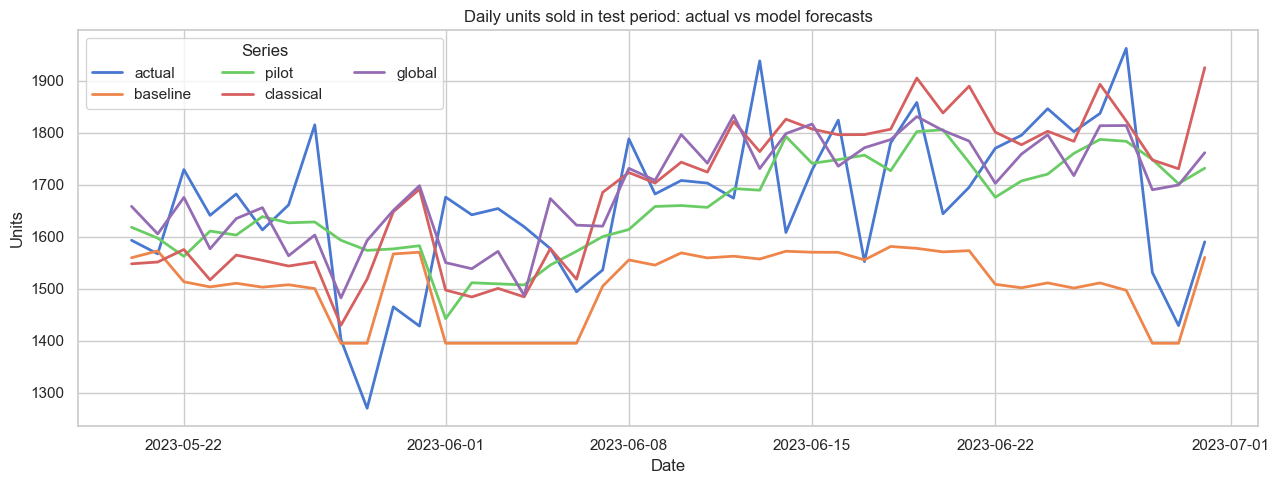

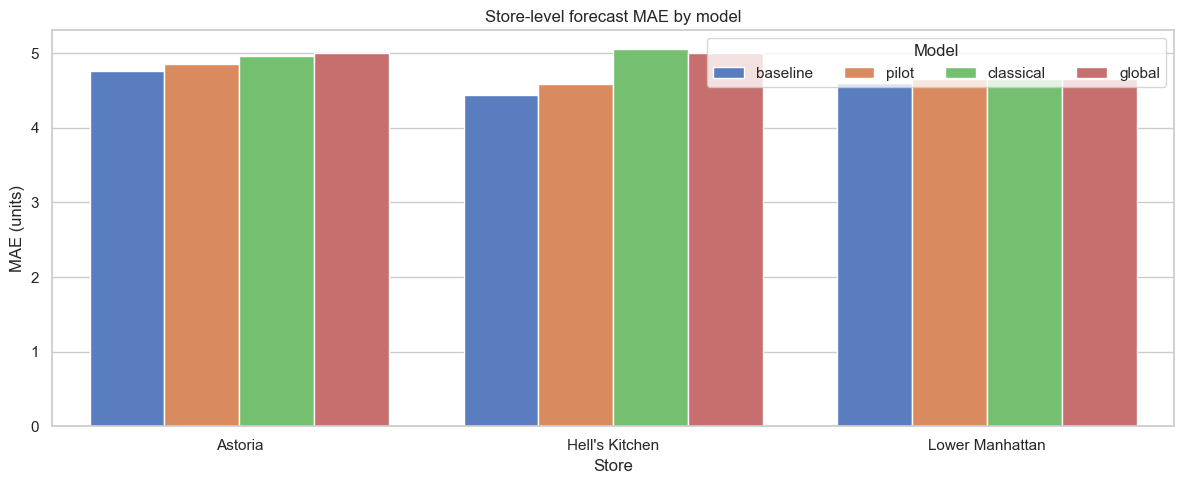

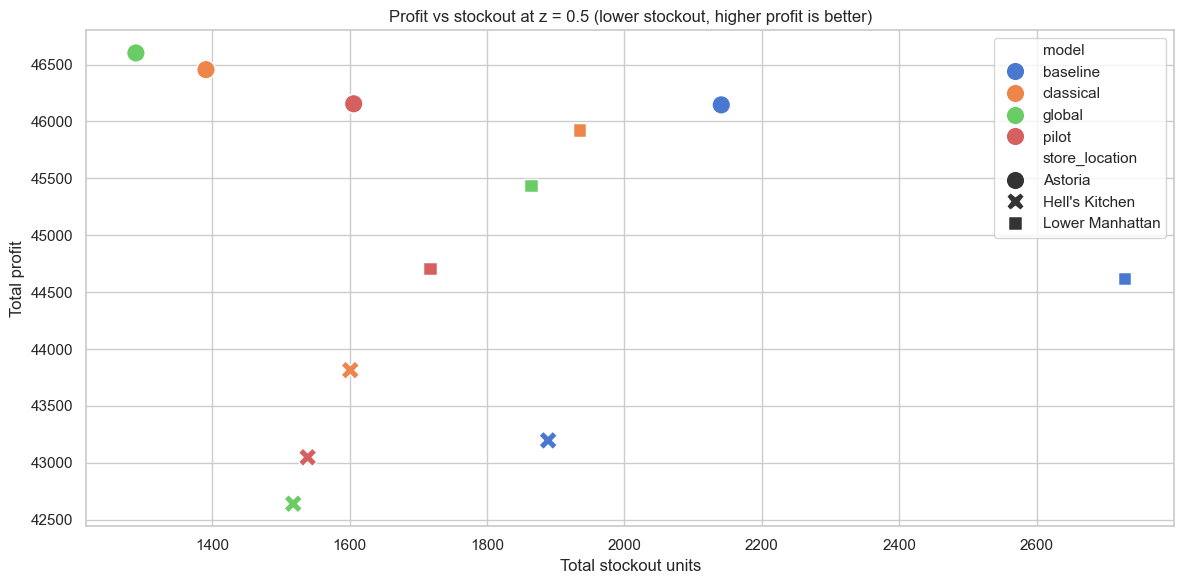

Key takeaway snapshot:
- chart 1 shows which model tracks daily demand pattern best
- chart 2 compares forecast accuracy by store
- chart 3 shows the business trade-off between profit and stockout


In [41]:
# Concise visual summary for Sections 10-15

required_vars = ['test', 'inv_df']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise ValueError(f"Run Sections 10-15 first. Missing: {missing}")

model_cols = ['baseline_pred', 'pilot_pred', 'classical_pred', 'global_pred']
model_name_map = {
    'baseline_pred': 'baseline',
    'pilot_pred': 'pilot',
    'classical_pred': 'classical',
    'global_pred': 'global',
}

for col in model_cols:
    if col not in test.columns:
        raise ValueError(f"Column '{col}' is missing from test. Re-run Sections 10-13.")

# 1) Daily aggregate demand: actual vs model forecasts
actual_daily = (
    test.groupby('date', as_index=False)['units_sold']
    .sum()
    .rename(columns={'units_sold': 'actual'})
)

pred_daily = test.groupby('date', as_index=False)[model_cols].sum()
pred_daily = pred_daily.rename(columns=model_name_map)

daily_plot = actual_daily.merge(pred_daily, on='date', how='left')
plot_long = daily_plot.melt(id_vars='date', var_name='series', value_name='units')

plt.figure(figsize=(13, 5))
sns.lineplot(data=plot_long, x='date', y='units', hue='series', linewidth=2)
plt.title('Daily units sold in test period: actual vs model forecasts')
plt.xlabel('Date')
plt.ylabel('Units')
plt.legend(title='Series', ncols=3, loc='upper left')
plt.tight_layout()
plt.show()

# 2) Store-level MAE by model
mae_rows = []
for store in sorted(test['store_location'].dropna().unique()):
    sub = test[test['store_location'] == store]
    for col in model_cols:
        mae_rows.append({
            'store': store,
            'model': model_name_map[col],
            'MAE': mean_absolute_error(sub['units_sold'], sub[col]),
        })

mae_df = pd.DataFrame(mae_rows)

plt.figure(figsize=(12, 5))
sns.barplot(data=mae_df, x='store', y='MAE', hue='model')
plt.title('Store-level forecast MAE by model')
plt.xlabel('Store')
plt.ylabel('MAE (units)')
plt.legend(title='Model', ncols=4, loc='upper right')
plt.tight_layout()
plt.show()

# 3) Profit-stockout trade-off at moderate risk (z = 0.5)
z_default = 0.5
tradeoff = (
    inv_df[inv_df['z_score'] == z_default]
    .groupby(['store_location', 'model'], as_index=False)
    .agg(
        total_profit=('profit', 'sum'),
        total_stockout=('stockout_qty', 'sum'),
        total_waste=('waste_cost', 'sum'),
    )
)

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=tradeoff,
    x='total_stockout',
    y='total_profit',
    hue='model',
    style='store_location',
    s=180,
)
plt.title('Profit vs stockout at z = 0.5 (lower stockout, higher profit is better)')
plt.xlabel('Total stockout units')
plt.ylabel('Total profit')
plt.tight_layout()
plt.show()

print('Key takeaway snapshot:')
print('- chart 1 shows which model tracks daily demand pattern best')
print('- chart 2 compares forecast accuracy by store')
print('- chart 3 shows the business trade-off between profit and stockout')

---

## Section 17 — Capacity-constrained product allocation

**Objective:** Given a fixed daily production capacity $C$ per store, determine how many units $Q_p$ of each product type to prepare in order to maximise profit.

**Optimisation setup:**
- **Decision variable:** $Q_p \geq 0,\; Q_p \in \mathbb{Z}$ (integer units per product\_type\_sized)
- **Constraint:** $\sum_p Q_p = C$ (capacity set to the store's average daily demand from training)
- **Objective:** $\max \sum_p \bigl[\min(Q_p,\, D_p)\cdot \text{price}_p \;-\; Q_p \cdot \text{unit\_cost}_p\bigr]$
- **Solution method:** greedy marginal-profit ranking — each "unit slot" up to predicted demand earns margin $(\text{price} - \text{unit\_cost})$; slots beyond demand incur waste cost. Top-$C$ slots are selected.

**Risk adjustment:** demand inflated via $\tilde{D}_p = \hat{D}_p + k \cdot \sigma_p$ with $k \in \{0,\, 0.5,\, 1.0\}$.

**Scope:** one randomly selected test day, all product types, each store separately, all four forecasting models.

In [42]:
import random
random.seed(42)

test_day = pd.Timestamp(random.choice(sorted(test['date'].unique())))

C_per_store = (
    daily_demand[daily_demand['date'] < cutoff_date]
    .groupby(['date', 'store_location'])['units_sold'].sum()
    .groupby('store_location').mean()
    .round().astype(int)
)

print(f"Randomly selected test day: {test_day.date()}\n")
print("Capacity C per store (mean daily training demand):")
for s in stores:
    print(f"  {s}: {C_per_store[s]} units")

# ── Build complete product frame for the selected day ──
day_full = full_grid[full_grid['date'] == test_day][[
    'store_location', 'product_type_sized', 'units_sold',
    'pilot_pred', 'global_pred', 'avg_unit_price', 'cogs_pct',
]].copy()

cl_day = classical_df[classical_df['date'] == test_day][[
    'store_location', 'product_type_sized', 'classical_pred'
]]
day_full = day_full.merge(cl_day, on=['store_location', 'product_type_sized'], how='left')

train_groups = (
    daily_demand[daily_demand['date'] < cutoff_date]
    .groupby(['store_location', 'product_type_sized'])
)
bl_vals = []
for _, r in day_full.iterrows():
    key = (r['store_location'], r['product_type_sized'])
    try:
        grp = train_groups.get_group(key)
        bl_vals.append(weighted_avg_forecast(grp, test_day))
    except KeyError:
        bl_vals.append(0.0)
day_full['baseline_pred'] = bl_vals

for c in ['pilot_pred', 'global_pred', 'classical_pred', 'baseline_pred']:
    day_full[c] = day_full[c].fillna(0)

day_full['unit_cost'] = day_full['avg_unit_price'] * day_full['cogs_pct']
day_full = day_full.sort_values(['store_location', 'product_type_sized']).reset_index(drop=True)

# ── Residual σ from test set ──
sigma_maps = {}
for col in MODEL_COLS:
    sigma_maps[col] = (
        test.groupby(['store_location', 'product_type_sized'])
        .apply(lambda g, c=col: (g['units_sold'] - g[c]).std())
    )

# ── Greedy profit-maximising allocator ──
def greedy_allocate(demands, prices, ucosts, C):
    n = len(demands)
    d_ceil = np.maximum(np.ceil(demands), 0).astype(int)
    margin = prices - ucosts
    Q = np.zeros(n, dtype=int)
    remaining = int(C)
    for i in np.argsort(-margin):
        if remaining <= 0:
            break
        alloc = min(remaining, int(d_ceil[i]))
        Q[i] = alloc
        remaining -= alloc
    if remaining > 0:
        Q[np.argmin(ucosts)] += remaining
    return Q

# ── Run optimisation for each store × model × risk level ──
K_VALUES = [0.0, 0.5, 1.0]
opt_rows = []

for store in stores:
    sd = day_full[day_full['store_location'] == store].reset_index(drop=True)
    C = C_per_store[store]
    prods = sd['product_type_sized'].values
    prices = sd['avg_unit_price'].values
    ucosts = sd['unit_cost'].values
    actuals = sd['units_sold'].values

    for col, mname in zip(MODEL_COLS, MODEL_NAMES):
        preds = np.maximum(sd[col].values, 0)
        sigs = np.array([sigma_maps[col].get((store, p), 0) for p in prods])
        sigs = np.nan_to_num(sigs, 0)

        for k in K_VALUES:
            adj = np.maximum(preds + k * sigs, 0)
            Q = greedy_allocate(adj, prices, ucosts, C)
            sold = np.minimum(Q, actuals)
            unsold = np.maximum(Q - actuals, 0)

            for i in range(len(prods)):
                opt_rows.append({
                    'store': store, 'model': mname, 'k': k,
                    'product': prods[i],
                    'predicted': round(float(preds[i]), 1),
                    'Q': int(Q[i]),
                    'actual': int(actuals[i]),
                    'sold': int(sold[i]),
                    'unsold': int(unsold[i]),
                    'price': round(float(prices[i]), 2),
                    'ucost': round(float(ucosts[i]), 2),
                })

opt_df = pd.DataFrame(opt_rows)

# ── Product-level allocation tables (k = 0, no risk buffer) ──
for store in stores:
    C = C_per_store[store]
    actual_total = int(day_full[day_full['store_location'] == store]['units_sold'].sum())
    print(f"\n{'=' * 72}")
    print(f"{store}  |  C = {C}  |  Actual total = {actual_total}  |  k = 0")
    print(f"{'=' * 72}")
    sd = opt_df[(opt_df['store'] == store) & (opt_df['k'] == 0.0)]
    pivot = sd.pivot_table(index='product', columns='model', values='Q', aggfunc='first')
    pivot['actual'] = sd.groupby('product')['actual'].first().values
    display(pivot[['baseline', 'pilot', 'classical', 'global', 'actual']])

# ── Profit & waste summary ──
print(f"\n{'=' * 72}")
print(f"PROFIT & WASTE SUMMARY — {test_day.date()}")
print(f"{'=' * 72}")

sum_rows = []
for store in stores:
    C = C_per_store[store]
    for mname in MODEL_NAMES:
        for k in K_VALUES:
            sub = opt_df[
                (opt_df['store'] == store) &
                (opt_df['model'] == mname) &
                (opt_df['k'] == k)
            ]
            revenue = (sub['sold'] * sub['price']).sum()
            cost = (sub['Q'] * sub['ucost']).sum()
            waste = (sub['unsold'] * sub['ucost']).sum()
            profit = revenue - cost
            stockout = int(np.maximum(sub['actual'] - sub['Q'], 0).sum())
            sum_rows.append({
                'store': store, 'model': mname, 'k': k, 'C': C,
                'profit': round(profit, 1),
                'waste': round(waste, 1),
                'stockout': stockout,
            })

sum_df = pd.DataFrame(sum_rows)

for store in stores:
    print(f"\n{store}:")
    ss = sum_df[sum_df['store'] == store]
    display(ss.pivot_table(
        index='model', columns='k',
        values=['profit', 'waste', 'stockout'],
    ).round(1))

print(f"\n{'=' * 72}")
print("BEST STRATEGY PER STORE (model + k with highest profit)")
print(f"{'=' * 72}")
best_idx = sum_df.groupby('store')['profit'].idxmax()
display(
    sum_df.loc[best_idx][['store', 'model', 'k', 'C', 'profit', 'waste', 'stockout']]
    .reset_index(drop=True)
)

Randomly selected test day: 2023-06-29

Capacity C per store (mean daily training demand):
  Astoria: 344 units
  Hell's Kitchen: 352 units
  Lower Manhattan: 345 units



Astoria  |  C = 344  |  Actual total = 585  |  k = 0


model,baseline,pilot,classical,global,actual
product,,,,,
Barista Espresso,31,41,37,31,38
Barista Espresso (lg),10,12,10,15,17
Barista Espresso (rg),11,14,11,14,7
Biscotti,15,0,0,0,16
Black tea,2,2,2,2,0
Brewed Black tea (lg),21,0,1,2,19
Brewed Black tea (rg),0,0,0,0,35
Brewed Chai tea (lg),34,44,48,37,47
Brewed Chai tea (rg),0,0,0,0,40



Hell's Kitchen  |  C = 352  |  Actual total = 420  |  k = 0


model,baseline,pilot,classical,global,actual
product,,,,,
Barista Espresso,44,49,62,34,58
Barista Espresso (lg),11,9,13,12,10
Barista Espresso (rg),11,14,15,16,10
Biscotti,14,14,0,1,10
Black tea,2,3,1,1,0
Brewed Black tea (lg),22,19,0,26,10
Brewed Black tea (rg),0,0,0,0,19
Brewed Chai tea (lg),29,33,39,34,38
Brewed Chai tea (rg),0,0,0,0,22


...

profit              stockout                waste              
k            0.0    0.5   1.0      0.0    0.5    1.0    0.0    0.5    1.0
model                                                                    
baseline   270.5  110.2 -51.6    176.0  195.0  215.0  370.0  490.5  607.2
classical  332.6  166.2  19.1    188.0  210.0  226.0  286.7  401.3  510.3
global     304.3  163.7 -59.0    198.0  204.0  233.0  286.5  415.4  569.5
pilot      354.0  194.5 -26.7    172.0  188.0  220.0  298.4  425.5  570.9


Lower Manhattan:


profit               stockout                waste              
k            0.0    0.5    1.0      0.0    0.5    1.0    0.0    0.5    1.0
model                                                                     
baseline   381.0  262.1  135.8    169.0  194.0  214.0  277.4  343.6  422.6
classical  443.8  300.8  124.6    178.0  202.0  240.0  200.3  286.7  371.5
global     452.2  318.0  162.5    174.0  198.0  229.0  199.3  278.9  360.1
pilot      274.1  140.1  -92.7    200.0  229.0  275.0  317.2  382.6  503.1


BEST STRATEGY PER STORE (model + k with highest profit)


,store,model,k,C,profit,waste,stockout
0,Astoria,global,0.0,344,552.4,216.2,297
1,Hell's Kitchen,pilot,0.0,352,354.0,298.4,172
2,Lower Manhattan,global,0.0,345,452.2,199.3,174


**Interpretation**

- On the sampled test day, actual demand exceeds the estimated capacity in all three stores, so scarcity is a real operational constraint rather than a theoretical one.
- When capacity is binding, the decision problem shifts from "how much total should we prepare" to "which products deserve the limited slots."
- That makes model-guided allocation most valuable on high-pressure days, where choosing the wrong mix can create both avoidable stockouts and avoidable waste.


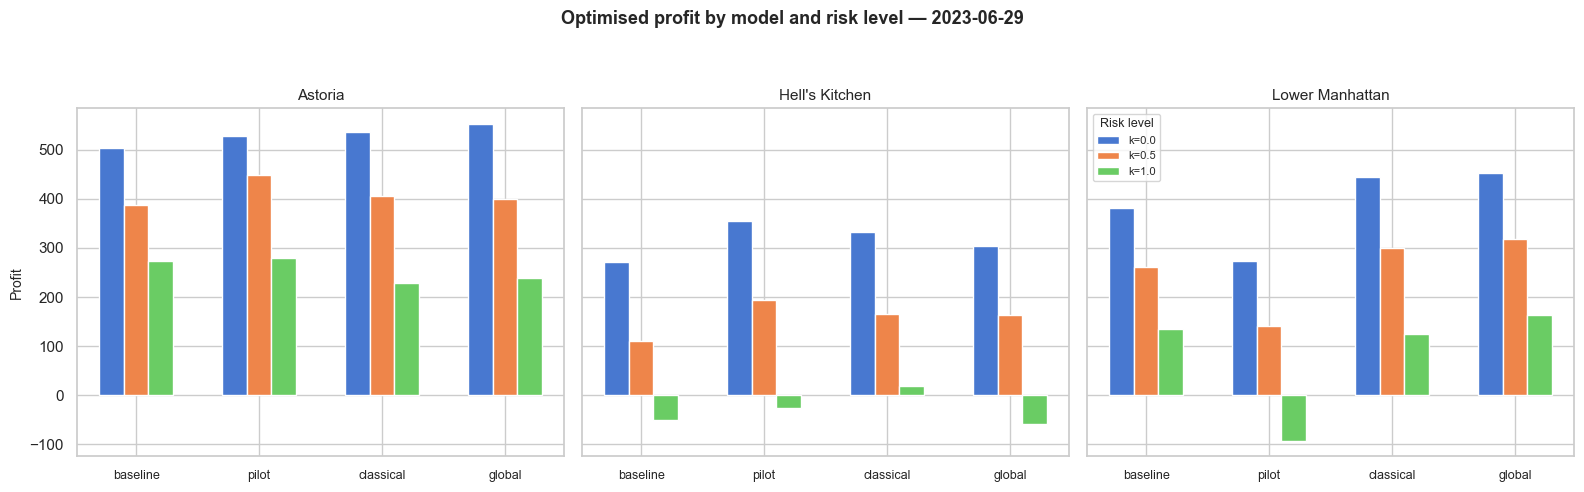

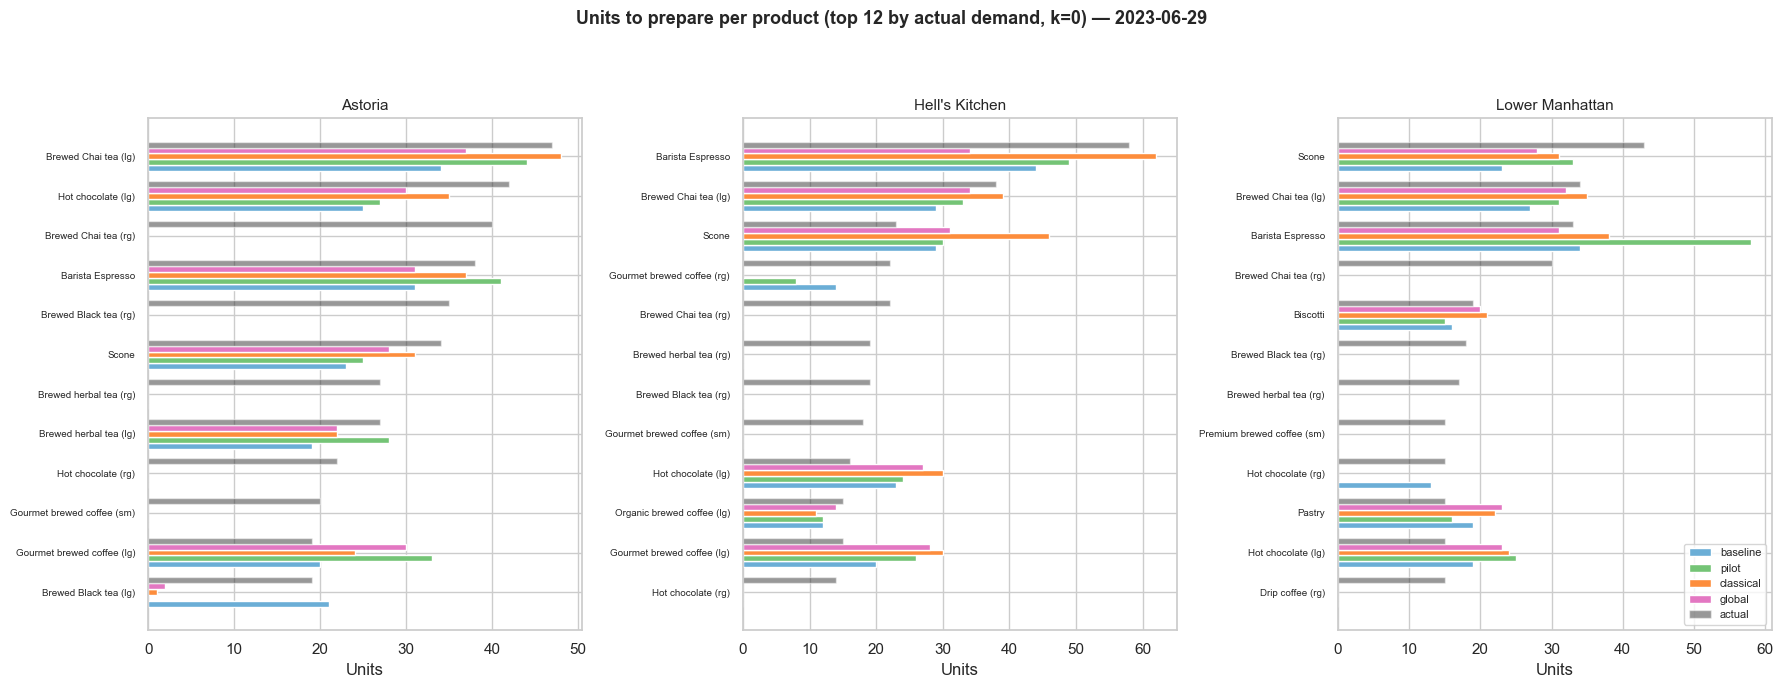

In [43]:
import matplotlib.pyplot as plt

for _v in ['test_day', 'sum_df', 'opt_df', 'K_VALUES', 'MODEL_NAMES', 'stores']:
    assert _v in dir(), f"Variable '{_v}' is missing — run Section 17 (cell above) first."

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.suptitle(
    f"Optimised profit by model and risk level — {test_day.date()}",
    fontsize=13, fontweight='bold',
)

bar_width = 0.2
k_labels = [f"k={k}" for k in K_VALUES]

for ax, store in zip(axes, stores):
    ss = sum_df[sum_df['store'] == store]
    x = np.arange(len(MODEL_NAMES))
    for j, k in enumerate(K_VALUES):
        profits = [
            float(ss[(ss['model'] == m) & (ss['k'] == k)]['profit'])
            for m in MODEL_NAMES
        ]
        ax.bar(x + j * bar_width, profits, bar_width, label=k_labels[j])
    ax.set_xticks(x + bar_width)
    ax.set_xticklabels(MODEL_NAMES, fontsize=9)
    ax.set_title(store, fontsize=11)
    ax.set_xlabel('')

axes[0].set_ylabel('Profit', fontsize=10)
axes[2].legend(title='Risk level', fontsize=8, title_fontsize=9)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

# ── Chart 2: Product allocation breakdown (top 12 products, k=0) ──
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 7))
fig2.suptitle(
    f"Units to prepare per product (top 12 by actual demand, k=0) — {test_day.date()}",
    fontsize=13, fontweight='bold',
)

for ax, store in zip(axes2, stores):
    sd = opt_df[(opt_df['store'] == store) & (opt_df['k'] == 0.0)]
    top_products = (
        sd.groupby('product')['actual'].first()
        .nlargest(12)
        .index.tolist()
    )
    sd_top = sd[sd['product'].isin(top_products)]
    pivot = sd_top.pivot_table(
        index='product', columns='model', values='Q', aggfunc='first'
    )[MODEL_NAMES]
    pivot['actual'] = sd_top.groupby('product')['actual'].first()
    pivot = pivot.sort_values('actual', ascending=True)

    y = np.arange(len(pivot))
    h = 0.15
    colours = ['#6baed6', '#74c476', '#fd8d3c', '#e377c2', '#333333']

    for j, col in enumerate(MODEL_NAMES):
        ax.barh(y + j * h, pivot[col], h, label=col, color=colours[j])
    ax.barh(y + len(MODEL_NAMES) * h, pivot['actual'], h,
            label='actual', color=colours[4], alpha=0.5)

    ax.set_yticks(y + h * 2)
    ax.set_yticklabels(pivot.index, fontsize=7)
    ax.set_title(store, fontsize=11)
    ax.set_xlabel('Units')

axes2[2].legend(fontsize=8, loc='lower right')
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()